Write your solution in here.

- Your code has to reference all data files using **relative** paths so that they can be loaded on other computers without modifications.
- All data files need to be stored in the `data/` folder.

For example: (REMOVE THIS)

In [1]:
import pandas as pd

# Define the path to the data directory
DATA_PATH = './data'

# Read the CSV using a relative path
df = pd.read_csv(f'{DATA_PATH}/sce_extract_2015.csv')

In [2]:
import time
start_time = time.time()

# Term Paper 2 - Expectations about Macroeconomic and Financial Variables

### Initial Setup - Modules, Display options, Data Path

In [3]:
# Modules
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
# Scikit-learn modules for regression and evaluation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# For correlation tables
from IPython.display import display, HTML


# Set display options for better readability
pd.set_option('display.max_columns', 50)

# Set plot style for consistent and visually appealing graphs
plt.style.use('seaborn-v0_8-whitegrid')

# Define the path to the data directory
DATA_PATH = './data'

## Part 1 - Data Preprocessing (SCE)

### 1.1 - Load SCE and Report Initial Sample Characteristics

In [4]:
def load_sce(DATA_PATH: str, file):
    """
    Load and concatenate SCE CSV files, keeping only relevant columns and parsing dates.

    Parameters
    ----------
    DATA_PATH : str
        Path to the directory containing the SCE CSV files.
    file : str
        Filename pattern used when reading individual CSV files.

    Returns
    -------
    tuple
        (COLS_FIRST_WAVE, COLS_META, COLS_EXPECTATIONS, COLS_INDIVIDUAL,
        ANALYSIS_COLS, ALL_COLS, sce) where sce is the concatenated DataFrame
        of all SCE survey waves.
    """
    # Define columns to read from the CSV files
    # Columns with variables only reported in the first wave of the survey
    COLS_FIRST_WAVE = ['owner','num_lit_q1_correct', 'num_lit_q2_correct', 'num_lit_q3_correct', 'num_lit_q5_correct', 'num_lit_q6_correct']
    # Columns with metadata
    COLS_META = ['userid', 'wid', 'date', 'tenure']
    # Columns with expectation-variables (Targets for modelling later)
    COLS_EXPECTATIONS = ['infl_1y', 'house_price_change', 'prob_unrate_up', 'prob_stocks_up']
    # Columns with individual characteristics
    COLS_INDIVIDUAL = ['female', 'hispanic', 'black', 'educ', 'hh_inc_bin_rank', 'working', 'couple', 'num_kids', 'age_init']
    # Combine all columns for analysis
    ANALYSIS_COLS = COLS_FIRST_WAVE + COLS_EXPECTATIONS + COLS_INDIVIDUAL
    # Combine all columns to read from the CSV files
    ALL_COLS  = COLS_META + ANALYSIS_COLS

    # Read and concatenate all CSV files, keeping only the relevant columns and parsing dates
    files = sorted(glob.glob(f'{DATA_PATH}/sce_extract_*.csv'))
    sce = pd.concat(
        (pd.read_csv(file, usecols=ALL_COLS, parse_dates=['date']) for file in files),
        ignore_index=True
    )
    return COLS_FIRST_WAVE, COLS_META, COLS_EXPECTATIONS, COLS_INDIVIDUAL, ANALYSIS_COLS, ALL_COLS, sce

In [5]:
# Load SCE data and store Columns in variables for later use
COLS_FIRST_WAVE, COLS_META, COLS_EXPECTATIONS, COLS_INDIVIDUAL, ANALYSIS_COLS, ALL_COLS, sce = load_sce(DATA_PATH, file=f'{DATA_PATH}/sce_extract_2015.csv')

# Number of observations, individuals, and survey waves in the initial dataset
n_obs_init   = len(sce)
n_ind_init   = sce['userid'].nunique()
n_waves_init = sce['wid'].nunique()

first_date_init = sce['date'].min().date()
last_date_init  = sce['date'].max().date()

# Print initial data summary
print("=== Initial sample ===")
print(f"  Observations : {n_obs_init:,}")
print(f"  Individuals  : {n_ind_init:,}")
print(f"  Survey waves : {n_waves_init}")
print(f"  Date range   : {first_date_init} → {last_date_init}")

=== Initial sample ===
  Observations : 180,268
  Individuals  : 23,886
  Survey waves : 143
  Date range   : 2013-06-01 → 2025-05-01


The individual-level features were selected based on two criteria: economic relevance as predictors of expectations, and data availability. Several variables were excluded due to a high share of missing values (20% or more), which would have substantially reduced the sample size: num_lit_q8_correct, num_lit_q9_correct, take_fin_risk, health, and self_employed. The survey sampling weight was dropped since not all scikit-learn estimators support sample weights.
Variables asked only at the first interview (owner, age_init, and the numerical literacy indicators) are forward-filled within each individual so that later waves carry the value from the first wave. Other expectation-related variables (e.g. infl_3y, prob_irate_up) are excluded as predictors, since they would not be available to a policymaker trying to forecast expectations in real time.

age_init was recorded at first interview, but carried forward prior to our analysis, hence why it's not in COLS_FIRST_WAVE. 

### 1.2 - Forward-fill First Wave Variables Within Each Individual

In [6]:
# Step 2 - Forward-fill within each individual (only fills NaNs after the first observed value)
sce[COLS_FIRST_WAVE] = (
    sce.groupby('userid')[COLS_FIRST_WAVE].ffill()
)

### 1.3 - Drop 2025 Observations to avoid Trump-Volatility

In [7]:
# Step 3 - Drop observations from 2025 due to Trump-volatility
mask_2025 = sce['date'].dt.year == 2025
n_dropped_2025 = mask_2025.sum()
sce = sce[~mask_2025].copy()
print(f"Step 3 — Dropped {n_dropped_2025:,} observations from 2025")

Step 3 — Dropped 4,167 observations from 2025


### 1.4 - Drop Missing Values in Analysis Columns

In [8]:
# Step 4 - Drop observations with missing values in the analysis columns
n_before = len(sce)
sce = sce.dropna(subset=ANALYSIS_COLS).copy()
print(f"Step 4 — Dropped {n_before - len(sce):,} observations with missing values")

Step 4 — Dropped 16,966 observations with missing values


### 1.5 - Trim outliers in Expectations Columns (Targets) at 1st and 99th Percentiles

## CONSIDER MASK AS TRIMMING METHOD HERE

In [9]:
# Step 5 - Trim outliers in expectation columns by capping values at the 1st and 99th percentiles
def trim_outliers(df, cols):
    """
    Drop rows where any specified column falls outside the 1st-99th percentile range.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame to filter.
    cols : list[str]
        Column names in which to trim outliers.

    Returns
    -------
    pd.DataFrame
        DataFrame with outlier rows removed for each specified column.
    """
    # Find percentiles for each column
    percentiles = {col: (df[col].quantile(0.01), df[col].quantile(0.99)) for col in cols}
    
    # Store the original number of observations before trimming
    obs_dropped = 0
    # Trim outliers for each column
    for col in cols:
        p1, p99 = percentiles[col]
        before = len(df)
        df = df[(df[col] > p1) & (df[col] < p99)]
        obs_dropped += before - len(df)
        print(f'  Trimmed {before - len(df):,} observations in column "{col}" outside [{p1:.2f}, {p99:.2f}]')

    # Final summary of outliers dropped
    print('-'*50)
    print(f"Step 5 — Dropped {obs_dropped:,} observations as outliers")
    
    return df

In [10]:
# Trim outliers in expectation columns
sce = trim_outliers(sce, COLS_EXPECTATIONS)

  Trimmed 3,400 observations in column "infl_1y" outside [-30.00, 60.00]
  Trimmed 3,790 observations in column "house_price_change" outside [-20.00, 50.00]
  Trimmed 4,034 observations in column "prob_unrate_up" outside [0.00, 100.00]
  Trimmed 2,394 observations in column "prob_stocks_up" outside [0.00, 95.00]
--------------------------------------------------
Step 5 — Dropped 13,618 observations as outliers


For prob_unrate_up, the 1st percentile is 0 and the 99th percentile is 100. Since the trimming condition is strictly > P1 and < P99, observations with values exactly equal to 0 or 100 are dropped. These are respondents who are completely certain about the direction of unemployment, which are valid responses rather than data errors - however, we follow the assignment instructions and apply the same rule to all four variables.
For prob_stocks_up, P99 = 95, meaning the top 1% of responses (above 95%) are removed as extreme outliers.

### 1.6 - Create Optimism Indicators

In [11]:
# Step 6 - Create Optimism indicators
sce['optimist_unrate']      = (sce['prob_unrate_up'] < 50).astype(int)
sce['optimist_stocks']      = (sce['prob_stocks_up'] > 50).astype(int)
sce['optimist_house_price'] = (sce['house_price_change'] > 0).astype(int)

# Store optimism indicators in a list for later use
OPTIMISM_COLS = ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']

ALL_COLS += OPTIMISM_COLS

### End Part 1: Display Initial and Final Sample Information

In [12]:
# Data cleaning summary
summary = pd.DataFrame({
    'Sample'       : ['Initial', 'Final', 'Difference'],
    'Observations' : [n_obs_init, len(sce), len(sce) - n_obs_init],
    'Individuals'  : [n_ind_init, sce['userid'].nunique(), sce['userid'].nunique() - n_ind_init],
    'Survey waves' : [n_waves_init, sce['wid'].nunique(), sce['wid'].nunique() - n_waves_init],
    'First date'   : [first_date_init, sce['date'].min().date(), 'No Change'],
    'Last date'    : [last_date_init, sce['date'].max().date(), f'{(sce["date"].max().date() - last_date_init).days} days'],
})
display(summary)

,Sample,Observations,Individuals,Survey waves,First date,Last date
0,Initial,180268,23886,143,2013-06-01,2025-05-01
1,Final,145517,21783,139,2013-06-01,2024-12-31
2,Difference,-34751,-2103,-4,No Change,-121 days


The final sample of $145,517$ observations is close to the target of ~$150,000$. Comment individuals and dates ... ...

## Part 2 - Data Preprocessing (Macro/Finance)

All macro and financial time series are downloaded and saved as CSV files in the "data" folder. **Yahoo Finance** data was downloaded programmatically using yfinance, while **FRED** data was downloaded manually from fred.stlouisfed.org. All series are resampled to monthly frequency. To avoid look-ahead bias, each series is shifted forward by one month so that a respondent interviewed in month $t$ only sees data available through the end of month $t−1$. For quarterly series (GDP, House Price Index), values are forward-filled within the quarter.

Additionally, we added two series not mentioned in the assignment - CBOE Volatility Index (VIX) and US 10-year treasury yield. 
- VIX captures uncertainty directly, which could be relevant for prob_stocks_up and general economic expectations.  
- The 10-year treasury yield as the long end of the yield curve embeds market participants' inflation and growth expectations, making it a good candidate for modelling infl_1y. 

Variables are included both in levels and as changes:

- Levels capture the current macroeconomic environment (e.g., high unemployment may anchor pessimism about future unemployment).
- 12-month changes capture recent momentum and surprises (e.g., a sharp rise in CPI may push inflation expectations higher regardless of the level).
- 1-month changes are computed for monthly series only and capture short-run surprises.
- VIX is kept only in levels since it is already a measure of reltive uncertainty. Percentage changes would be harder to interpret economically. 

For series expressed as index or price levels (CPI, House Price Index, Real GDP, USD Index, WTI Crude Oil, S&P 500), changes are expressed as percentage growth rates, since a one-unit absolute difference is not economically meaningful. For series already expressed in percentage terms (Federal Funds Rate, Unemployment Rate, 30-Year Mortgage Rate), changes are expressed as percentage-point differences, since a relative change (e.g. "the fed funds rate doubled") would be misleading when the level is near zero.
The final selection of which transformations to use as predictors is deferred to Parts 5 and 6, guided by the correlation analysis in Part 4.

In [13]:
def load_yahoo(data_path: str) -> pd.DataFrame:
    """
    Load Yahoo Finance data from CSV files, resample to monthly frequency, and compute changes.

    Parameters
    ----------
    data_path : str
        Path to the directory containing the Yahoo Finance CSV files.

    Returns
    -------
    pd.DataFrame
        Monthly panel with price levels and 1-month / 12-month percentage changes
        for WTI crude oil and the S&P 500, shifted one month to avoid look-ahead bias.
    """
    # Define the mapping of column names to their corresponding CSV filenames
    files = {
        'wti_crude_oil': 'wti_crude_oil.csv',
        'sp500':         'sp500.csv',
    }

    monthly = []
    for col, filename in files.items():
        df = pd.read_csv(f'{data_path}/{filename}', parse_dates=['date'], index_col='date')
        print(f'Loaded {col} with {len(df):,} observations from {df.index.min().date()} to {df.index.max().date()}')

        m = df.resample('ME').last()
        m[f'{col}_chg']     = m[col].pct_change()
        m[f'{col}_chg12m'] = m[col].pct_change(12)
        monthly.append(m.shift(1))

    # COncatenate all processed series
    out = pd.concat(monthly, axis=1)
    # Shift all series by one month to avoid look-ahead bias and sort by index
    out = out.shift(1).sort_index()
    # Limit date range to match the SCE data
    out = out[(out.index >= sce['date'].min()) & (out.index <= sce['date'].max())]

    return out

In [14]:
# Load Yahoo Finance data
yahoo = load_yahoo(DATA_PATH)

Loaded wti_crude_oil with 3,772 observations from 2010-01-04 to 2024-12-31
Loaded sp500 with 3,774 observations from 2010-01-04 to 2024-12-31


Yahoo Finance series are loaded and merged, with 1-month and 12-month change calculations performed, and observations shifted by a month.

Note that date range is not limited to SCE data at this point, and with the data starting in January 2010 all returns variables have some NA's. After merging with macro and SCE, there will be none. 

In [15]:
# Reusable function to load and preprocess FRED data based on the configuration
def load_fred(data_path: str, config: dict) -> pd.DataFrame:
    """
    Load, resample, compute changes, and shift FRED series to monthly frequency.

    Parameters
    ----------
    data_path : str
        Path to the directory containing the FRED CSV files.
    config : dict
        Mapping of series name -> (filename, is_quarterly, chg_fn) where
        is_quarterly indicates whether the series is quarterly (bool) and
        chg_fn is one of "pct", "diff", or None.

    Returns
    -------
    pd.DataFrame
        Monthly panel of FRED series with level and change columns,
        shifted one month to avoid look-ahead bias.
    """
    # Dictionary to hold the processed series
    series = {}
    # Load, resample, compute changes, and shift each series according to the configuration
    for name, (fname, is_quarterly, chg_fn) in config.items():
        # Load the CSV file for the series
        s = pd.read_csv(
            f"{data_path}/{fname}",
            parse_dates=[0], index_col=0,
            header=0, names=["date", name],
        )
        # If the series is quarterly, adjust the index to represent the end of the quarter
        if is_quarterly:
            s.index = s.index + pd.offsets.QuarterEnd(0)
        s_m = s.resample("ME").last()
        if is_quarterly:
            s_m = s_m.ffill()

        # Compute changes based on the specified change function
        if chg_fn == "pct":
            s_m[f"{name}_chg12m"] = s_m[name].pct_change(12, fill_method=None) * 100
            if not is_quarterly:
                s_m[f"{name}_chg1m"] = s_m[name].pct_change(1, fill_method=None) * 100
        elif chg_fn == "diff":
            s_m[f"{name}_chg12m"] = s_m[name].diff(12)
            if not is_quarterly:
                s_m[f"{name}_chg1m"] = s_m[name].diff(1)
        elif chg_fn is not None:
            raise ValueError(f"Unknown change type {chg_fn!r} for series {name!r}")
        
        # Store the processed series in the dictionary
        series[name] = s_m

    # Concatenate all processed series
    out = pd.concat(series.values(), axis=1)
    # Shift all series by one month to avoid look-ahead bias and sort by index
    out = out.shift(1).sort_index()
    # Limit date range to match the SCE data
    out = out[(out.index >= sce['date'].min()) & (out.index <= sce['date'].max())]

    return out

In [16]:
# Configuration: name -> (filename, is_quarterly, change_type)
# pct: price/index series — changes as % growth rates
# diff: series already in % terms — changes as percentage-point differences
# None: no change computed for VIX
FRED_CONFIG = {
    "cpi":              ("CPIAUCSL.csv",     False, "pct"),
    "house_price_idx":  ("USSTHPI.csv",      True,  "pct"),
    "federal_funds":    ("FEDFUNDS.csv",     False, "diff"),
    "unemployment":     ("UNRATE.csv",       False, "diff"),
    "real_gdp":         ("GDPC1.csv",        True,  "pct"),
    "usd_index":        ("DTWEXBGS.csv",     False, "pct"),
    "mortgage_30y":     ("MORTGAGE30US.csv", False, "diff"),
    "10y_yield":        ("DGS10.csv",        False, "diff"),
    "vix":              ("VIXCLS.csv",       False, None),
}

# Load FRED data
fred = load_fred(DATA_PATH, FRED_CONFIG)

Macro data sets are loaded and merged, with 1-month and 12-month changes calculated for all variables (except VIX).

In [17]:
# Reusable function to merge yahoo, FRED, and SCE data on a monthly basis
def merge_all(sce: pd.DataFrame, yahoo: pd.DataFrame, fred: pd.DataFrame):
    """
    Merge SCE survey data with Yahoo Finance and FRED macro data on a monthly basis.

    Parameters
    ----------
    sce : pd.DataFrame
        SCE survey DataFrame with a 'date' column of interview dates.
    yahoo : pd.DataFrame
        Monthly Yahoo Finance panel indexed by month-end dates.
    fred : pd.DataFrame
        Monthly FRED macro panel indexed by month-end dates.

    Returns
    -------
    tuple
        (sce_data, macro_all, MACRO_COLS, ALL_COLS) where sce_data is the
        merged individual-level DataFrame, macro_all is the combined macro
        panel, and MACRO_COLS / ALL_COLS are the updated column lists.
    """
    # Merge Yahoo Finance data into the monthly macro panel (Combine in reusable function for loading and processing FRED/Yahoo data?)
    macro_all = fred.join(yahoo, how="left")
    macro_all = macro_all.sort_index()

    # Prepare macro_all for merging: reset date index into a column named 'date_me'
    macro_for_merge = macro_all.rename_axis('date_me').reset_index()

    # Prepare SCE data for merging: create a month-end date key (date_me) that maps each interview date to the corresponding month-end
    sce['date_me'] = sce['date'] + pd.offsets.MonthEnd(0)

    # Left-join SCE with macro panel, then drop the temporary merge key
    sce_data = sce.merge(macro_for_merge, on='date_me', how='left').drop(columns=['date_me'])

    # Store the list of macro/finance columns for later use (all columns that are not in the previously defined set)
    MACRO_COLS = [
        c for c in sce_data.columns
        if c not in set(ALL_COLS) 
    ]
    
    # Update ALL_COLS to include the new macro/finance columns
    ALL_COLS.extend(MACRO_COLS)

    # Returns the merged dataset along with the updated column lists
    return sce_data, macro_all, MACRO_COLS, ALL_COLS

In [18]:
# Merge all datasets into a single DataFrame for analysis, store new columns and updated column list for later use
sce_data, macro_all, MACRO_COLS, ALL_COLS = merge_all(sce, yahoo, fred)

All macroeconomic and finance data merged with SCE, limited to SCE date range and shifted by a month to reflect real time information. 

## Part 3 - Exploratory Data Analysis (SCE)

In [19]:
# Plot prep: create lists of (column, title) pairs for plotting
exp_labels = [
    'Inflation Expectations (1 Year)',
    'House Price Change Expectations',
    'Unemployment Rate Increase Probability',
    'Stock Market Increase Probability',
]
exp_plot_vars = list(zip(COLS_EXPECTATIONS, exp_labels))

# Optimism indicators labels
opt_titles = [
    'Unemployment Optimists (prob < 50%)',
    'Stock Market Optimists (prob > 50%)',
    'House Price Optimists (change > 0%)'
]

opt_plot_vars = list(zip(OPTIMISM_COLS, opt_titles))

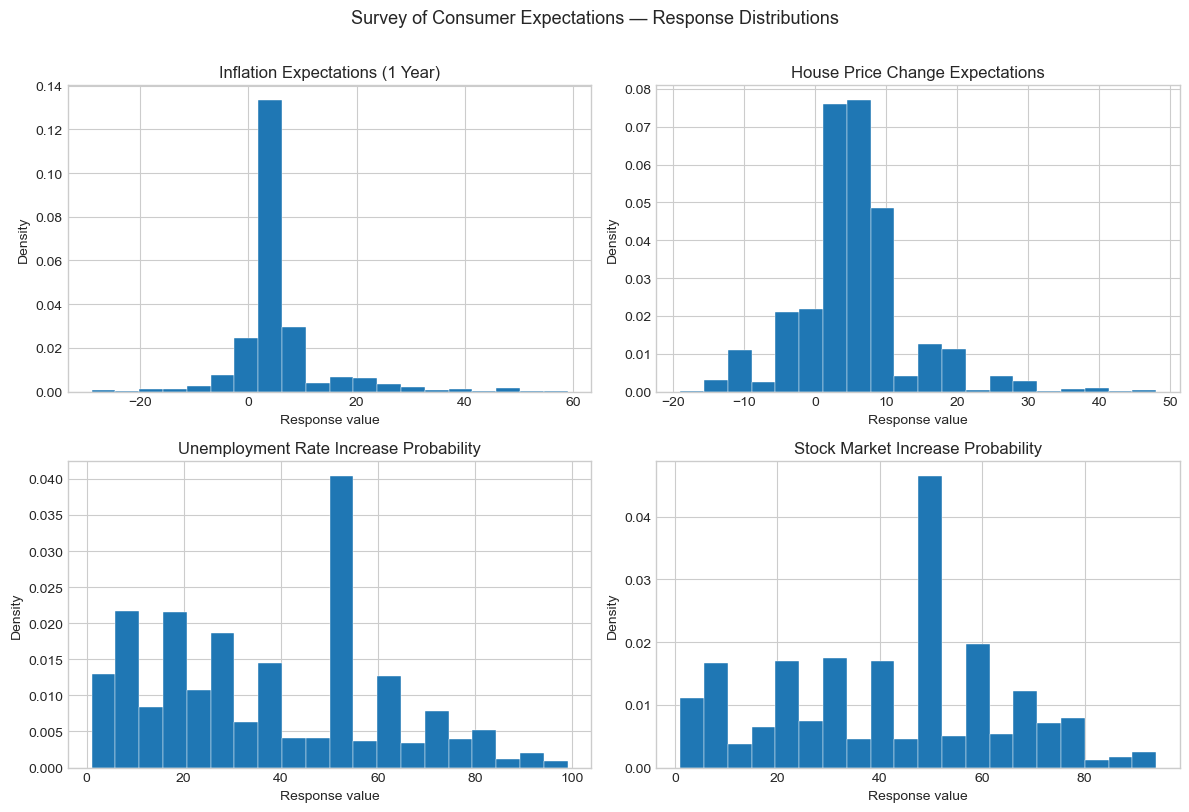

In [20]:
# Step 1 - Histograms of the key expectation variables to visualize their distributions after cleaning
# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loop through the variables and create histograms
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.hist(sce_data[col].dropna(), bins=20, edgecolor='white', linewidth=0.3, density=True)
    ax.set_title(title)
    ax.set_xlabel('Response value')
    ax.set_ylabel('Density')

# Final adjustments and show the plot
fig.suptitle('Survey of Consumer Expectations — Response Distributions', fontsize=13, y=1.01)
_ = plt.tight_layout()

All four distributions show strong bunching at round numbers - respondents tend to report values in multiples of 5 or 10, which is a well-known feature of survey data. Expected inflation is right-skewed with a sharp peak near zero, reflecting that most respondents expect low but positive inflation. Expected house price change is similarly concentrated around small positive values. The probability variables (prob_unrate_up and prob_stocks_up) show pronounced spikes at 50, suggesting many respondents express maximal uncertainty by reporting exactly 50%. Note that these histograms are presented after trimming outliers P1 and P99. The distributions still show signs of some strong outliers, mainly in the first two subplots. 

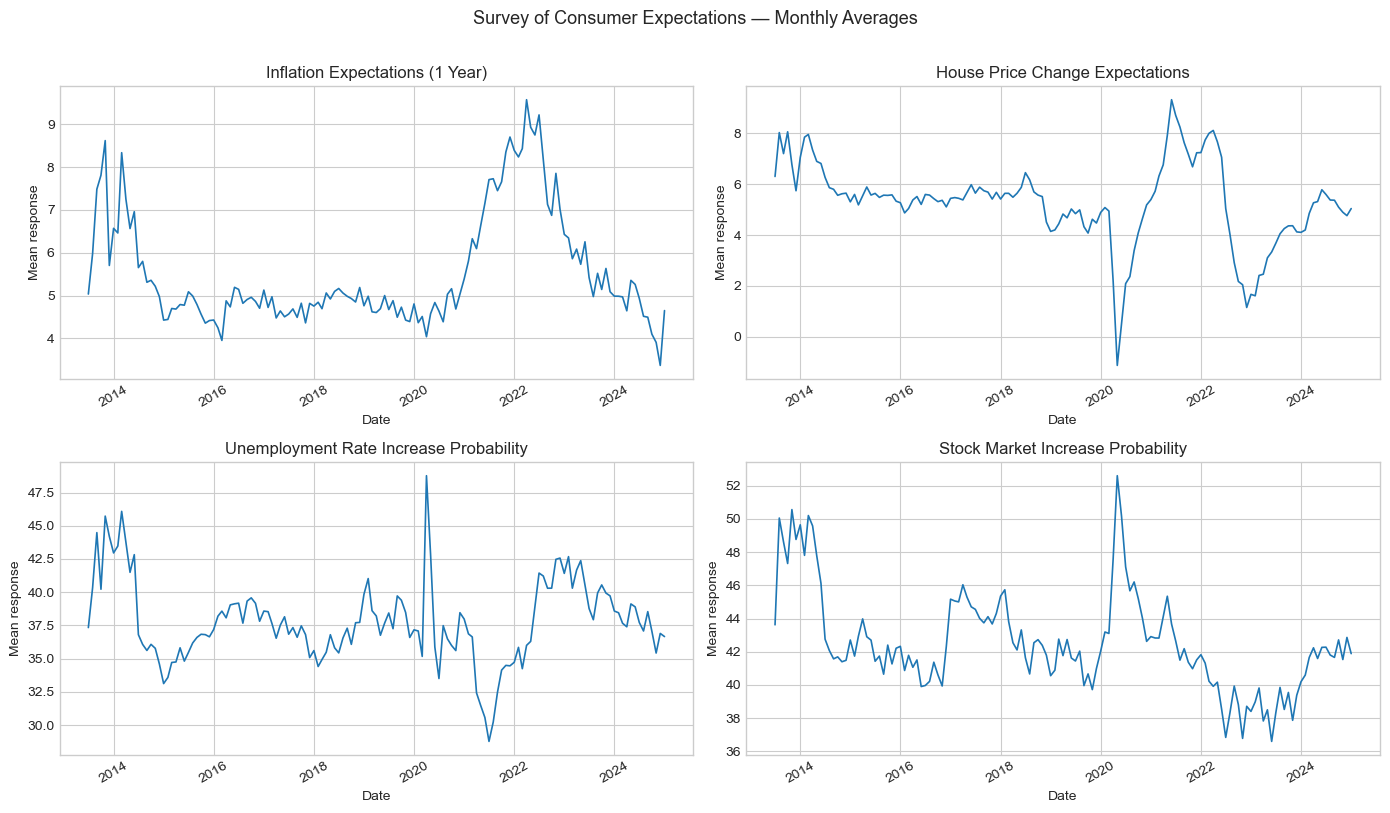

In [21]:
# Step 2 - Time series plots of the key expectation variables (monthly averages) to visualize trends and cycles
# Compute monthly means for the expectation variables using the month-end date key (date_me) to group by month
monthly_means = (
    sce_data
    .groupby(pd.Grouper(key='date', freq='ME'))[COLS_EXPECTATIONS]
    .mean()
)

# Create a 2x2 grid of subplots for the expectation variables
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Loop through the variables and create time series plots (Variables and titles defined in the previous step as plot_vars)
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.plot(monthly_means.index, monthly_means[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Mean response')
    ax.tick_params(axis='x', rotation=30)

# Final adjustments and show the plot
fig.suptitle('Survey of Consumer Expectations — Monthly Averages', fontsize=13, y=1.01)
_ = plt.tight_layout()

Inflation expectations were elevated in 2013–2014, declined to a stable low around 4–5% through 2015–2019, then surged sharply from 2021 peaking above 9% in 2022 during the post-COVID inflation episode before declining again. House price expectations collapsed in early 2020 (COVID shock) but recovered rapidly. Unemployment pessimism spiked briefly in March–April 2020 before reverting. Stock market optimism has remained persistently below 50% throughout the sample, suggesting consumers are generally pessimistic about equity market gains.

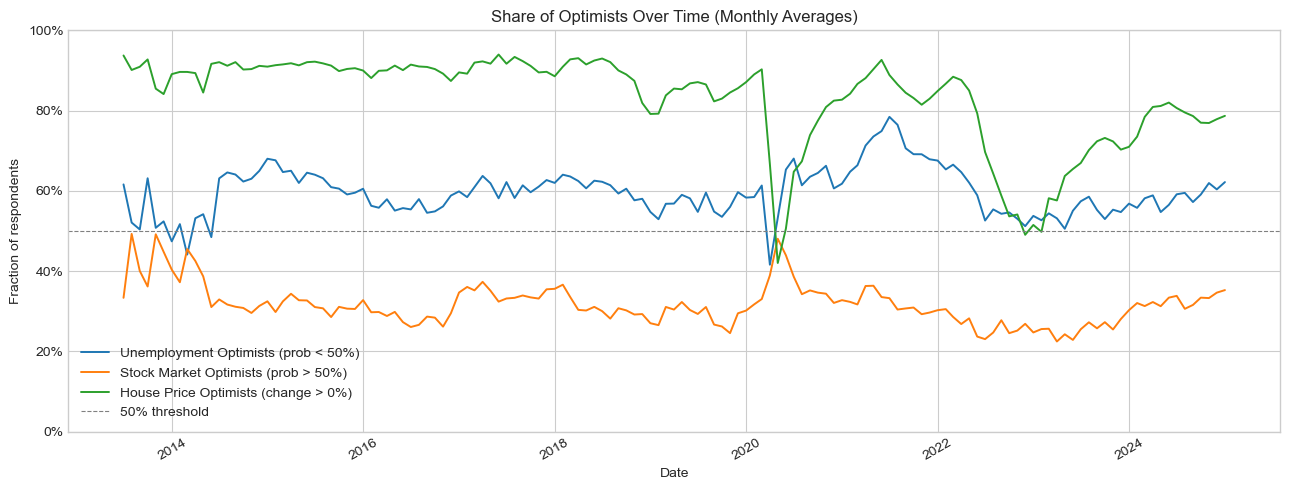

In [22]:
# Step 3 - Plot the share of optimists over time (monthly averages) to visualize trends and cycles in optimism
# Compute monthly means of the optimism indicators (performed on sce as macro/finance in sce_data is not needed here - computational efficiency)
optimism_means = (
    sce
    .groupby(pd.Grouper(key='date', freq='ME'))[OPTIMISM_COLS]
    .mean()
)

# Initialize the plot
fig, ax = plt.subplots(figsize=(13, 5))

# Plot each optimism indicator over time
for col, title in opt_plot_vars:
    ax.plot(optimism_means.index, optimism_means[col], linewidth=1.4, label=title)

# Format y-axis as percentages, set limits, add a horizontal line at 50%, and finalize the plot
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_xlabel('Date')
ax.set_ylabel('Fraction of respondents')
ax.set_title('Share of Optimists Over Time (Monthly Averages)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

_ = plt.tight_layout()

House price optimists consistently make up the large majority of respondents (~85–90% in normal times), reflecting a deeply held belief that house prices tend to rise. Stock market optimists are consistently the minority (~30–35%), suggesting persistent pessimism about equities among households. The COVID shock in early 2020 is visible as a sharp drop in House price and Unemployment optimists, and a spike in Stock market optimists, followed by a rapid recovery. House price optimists also dropped significantly around 2023.

## Part 4 - Exploratory Data Analysis (Macro/Finance)

In [23]:
# Plot prep: create lists of (column, title) pairs for plotting
# Macro vars as levels (original values)
macro_vars = [
    ('cpi', 'Consumer Price Index (CPI)'),
    ('house_price_idx', 'House Price Index'),
    ('federal_funds', 'Federal Funds Rate (%)'),
    ('unemployment', 'Unemployment Rate (%)'),
    ('real_gdp', 'Real GDP (Billions of Chained 2012 Dollars)'),
    ('usd_index', 'US Dollar Index'),
    ('mortgage_30y', '30-Year Fixed Mortgage Rate (%)'),
    ('sp500', 'S&P 500 Index Level'),
    ('wti_crude_oil', 'WTI Crude Oil Price (USD)'),
    ('10y_yield', '10-Year Treasury Yield (%)'),
    ('vix', 'VIX Volatility Index'),
]

# Macro vars as changes (12-month changes for all, plus 1-month changes for non-quarterly series)
macro_vars_changes = [
    ('cpi_chg12m',             'CPI Inflation YoY (%)'),
    ('cpi_chg1m',              'CPI Inflation MoM (%)'),
    ('federal_funds_chg12m',   'Fed Funds Rate 12m Change (pp)'),
    ('federal_funds_chg1m',    'Fed Funds Rate 1m Change (pp)'),
    ('unemployment_chg12m',    'Unemployment Rate 12m Change (pp)'),
    ('unemployment_chg1m',     'Unemployment Rate 1m Change (pp)'),
    ('mortgage_30y_chg12m',    '30Y Mortgage Rate 12m Change (pp)'),
    ('mortgage_30y_chg1m',     '30Y Mortgage Rate 1m Change (pp)'),
    ('usd_index_chg12m',       'USD Index 12m Change (%)'),
    ('usd_index_chg1m',        'USD Index 1m Change (%)'),
    ('house_price_idx_chg12m', 'House Price Index 12m Change (%)'),
    ('real_gdp_chg12m',        'Real GDP 12m Change (%)'),
    ('sp500_chg',              'S&P 500 Monthly Return (%)'),
    ('sp500_chg12m',          'S&P 500 12m Return (%)'),
    ('wti_crude_oil_chg12m',  'WTI Crude Oil 12m Return (%)'),
    ('10y_yield_chg12m',   '10-Year Treasury Yield 12m Change (pp)'),
    ('10y_yield_chg1m',    '10-Year Treasury Yield 1m Change (pp)')
]

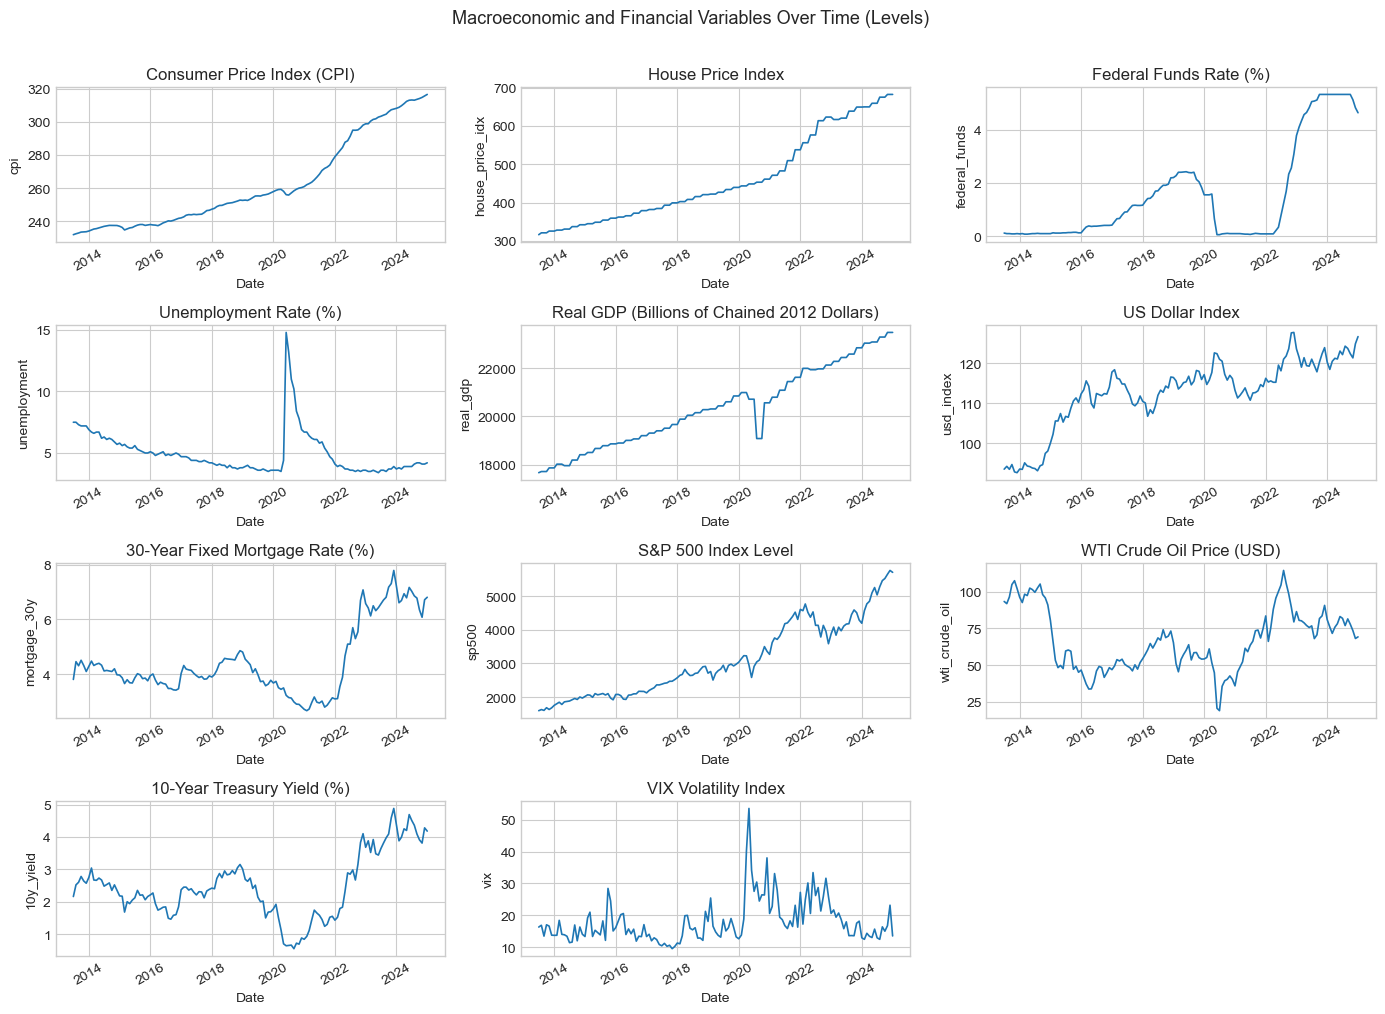

In [24]:
# Step 1 - Plot macro/finance variables in levels over time
# Initialize a 4x3 grid of subplots for the macro/finance variables
fig, axes = plt.subplots(4, 3, figsize=(14, 10))

# Loop through the macro and finance variables and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=30)

# Final adjustments and show the plot
axes.flat[-1].set_visible(False)  # Hide the last empty subplot
fig.suptitle('Macroeconomic and Financial Variables Over Time (Levels)', fontsize=13, y=1.01)
_ = plt.tight_layout()

The levels plots reveal several key macroeconomic trends over the sample period. CPI and house prices grew steadily throughout, with house prices accelerating sharply post-2020. The Federal Funds Rate and mortgage rate dropped to near zero during COVID and rose sharply in 2022–2023 as the Fed tightened monetary policy. Unemployment spiked dramatically in early 2020 before recovering rapidly. The S&P 500 trended upward throughout with a sharp correction in early 2020. WTI crude oil was volatile, collapsing in 2020 before recovering. VIX spiked sharply in early 2020, reflecting peak market uncertainty during the pandemic.

# REMEMBER TO SET YLABEL BELOW

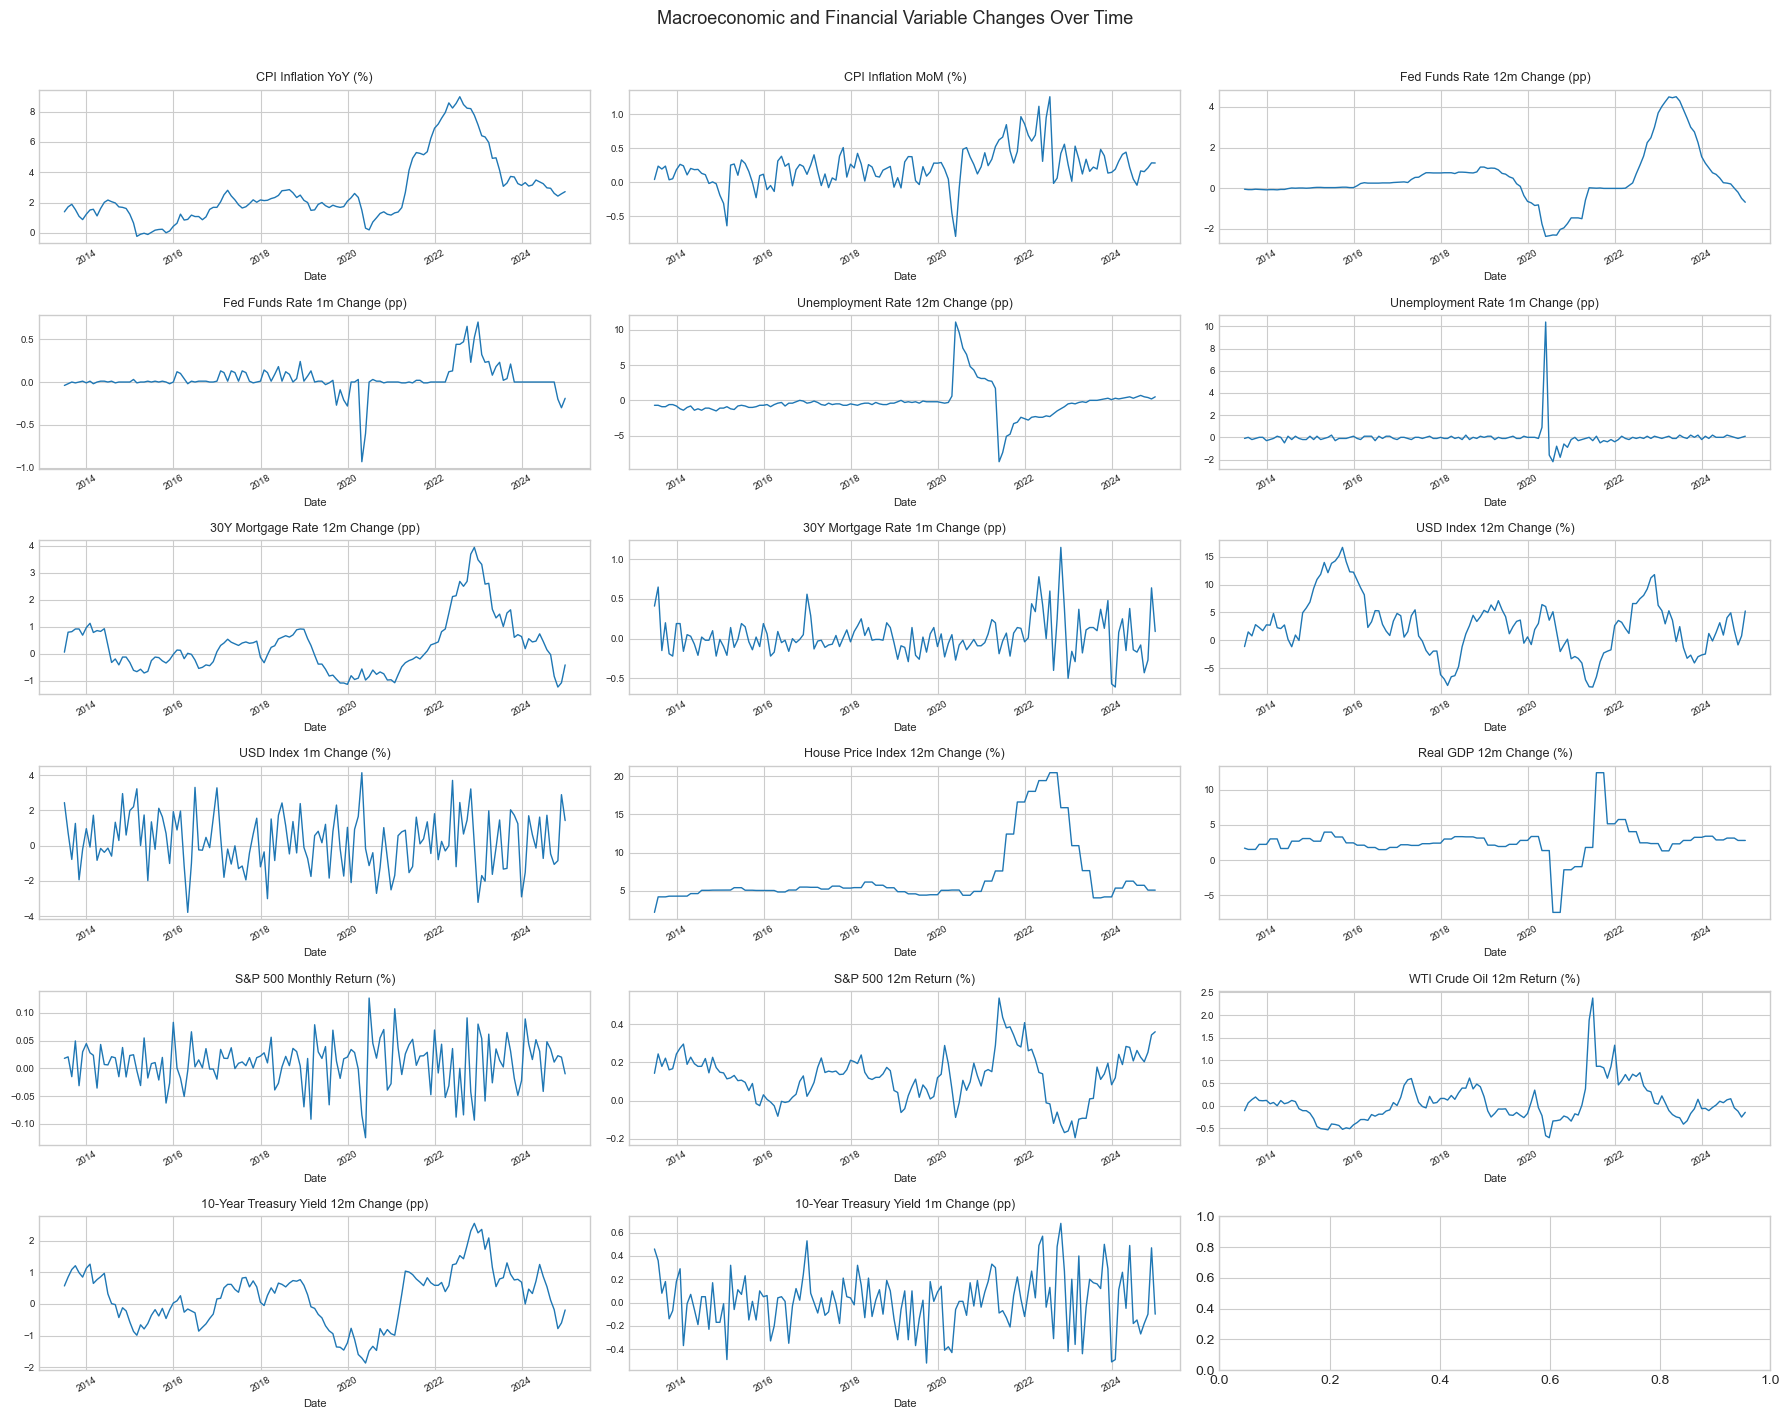

In [25]:
# Step 2 - Plot macro/finance variables in relative/absolute changes over time
# Initialize a 6x3 grid of subplots for the macro/finance variables in changes
fig, axes = plt.subplots(6, 3, figsize=(18, 14))

# Loop through the macro and finance variables in changes and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars_changes):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Date', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Final adjustments and show the plot
fig.suptitle('Macroeconomic and Financial Variable Changes Over Time', fontsize=13, y=1.01)
_ = plt.tight_layout()

The changes plots highlight episodes of macroeconomic stress more clearly than the levels. CPI inflation surged in 2021–2022 to multi-decade highs before declining. The Federal Funds Rate saw its largest 12-month increase in decades during 2022–2023. Unemployment changes were dominated by the COVID shock. S&P 500 and WTI returns show high volatility throughout, with large negative values in early 2020. The 10-year yield changes mirror the Federal Funds Rate, rising sharply in 2022.

In [26]:
# Step 3 - Correlation between macro/finance variables and expectations variables
# Build all four styled tables as HTML strings
html_tables = []
for target in COLS_EXPECTATIONS:
    corr = (
        sce_data[MACRO_COLS]
        .corrwith(sce_data[target])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.15)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {target}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
house_price_idx_chg12m,0.13
cpi_chg12m,0.12
wti_crude_oil_chg12m,0.09
cpi_chg1m,0.09
wti_crude_oil,0.08
10y_yield_chg12m,0.08
mortgage_30y_chg12m,0.07
sp500,0.06
unemployment_chg12m,-0.06
house_price_idx,0.05


Overall correlations between macro/finance variables and expectations are modest, with no variable exceeding 0.13 in absolute value. This suggests that macro variables alone have limited predictive power for individual-level expectations, which is consistent with the literature on heterogeneous beliefs. The strongest predictors of inflation expectations are house price momentum (house_price_idx_chg12m) and CPI changes, which is intuitive. For house price expectations, S&P 500 12-month returns and WTI crude oil returns are most correlated, suggesting that financial market sentiment spills over into housing expectations. Unemployment and stock market expectations show weaker macro correlations overall. VIX shows modest negative correlations with house_price_chg and prob_stocks_up, consistent with the view that higher uncertainty suppresses optimism about asset prices. Note that correaltions are computed on the full data set - not split in train and test.

## Part 5

This section fits regression models to predict the four continuous expectations variables. We follow a two-step approach: first using only macro/finance variables as features, then augmenting with individual-level SCE variables. For each model we use 5-fold cross-validation to select hyperparameters where applicable, plot validation curves, and evaluate performance on the 2024 test set using RMSE and R².

For the macro/finance features, we include both levels and 12-month changes. Levels capture the current macroeconomic environment (e.g. a high federal funds rate signals tight monetary policy), while 12-month changes capture recent momentum and surprises. From the 12-month change variables we select the house price index, cpi, wti crude oil, sp500 and unemployment. In 1-month changes we include cpi, and in levels unemployment, federal funds, mortgage 30y, 10y yield and vix. All of these have relatively strong correlation with the targets, compared to the rest of the data set. 

For the individual-level SCE features, we select variables based on the correlation analysis below. Income rank, education, and numerical literacy show the strongest correlations with the target variables and are therefore included. female, black and working are also included as they show consistent correlations across multiple targets. Multicollinearity between the literacy variables is highly likely, but we still want to include a few of them: we pick q2, q3, and q6, as they display consistently high correlation with the targets. The multicollinearity will be handled for all models except OLS through regularization. educ is included as a categorical variable and one-hot encoded.

Model descriptions:

We fit five models for each target variable and feature set:

- **OLS**: No Hyperparameters. Requires feature scaling (StandardScaler applied). Serves as the baseline.
- **Ridge**: L2 regularization with penalty strength α. Requires feature scaling. α selected via 5-fold Cross Validation.
- **Lasso**: L1 regularization with penalty strength α. Requires feature scaling. α selected via 5-fold Cross Validation. Can shrink coefficients to exactly zero, effectively performing feature selection.
- **ElasticNet**: Combines L1 and L2 regularization. Requires feature scaling. Both α and l1_ratio selected via 5-fold Cross Validation. 
- **DecisionTree**: No feature scaling needed. max_depth selected via 5-fold Cross Validation. Captures non-linear relationships. 

In [27]:
# For choice of SCE predictors - correlation with targets 

# Build all four styled tables as HTML strings
html_tables = []
for target in COLS_EXPECTATIONS:
    corr = (
        sce_data[COLS_FIRST_WAVE + COLS_INDIVIDUAL]
        .corrwith(sce_data[target])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.15)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {target}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
hh_inc_bin_rank,-0.17
educ,-0.16
num_lit_q2_correct,-0.16
num_lit_q6_correct,-0.14
num_lit_q3_correct,-0.13
female,0.13
black,0.12
num_lit_q5_correct,-0.10
owner,-0.07
couple,-0.06


In [28]:
# Feature sets for Part 5 - Chosen based on Correlation analysis and theoretical considerations.
NUM_MACRO = [
    "house_price_idx_chg12m", "cpi_chg12m", "cpi_chg1m",
    "wti_crude_oil_chg12m", "sp500_chg12m",
    "unemployment_chg12m", "unemployment",
    "federal_funds", "mortgage_30y", "10y_yield",
    "vix",
]
# SCE variables that don't need encoding.
NUM_SCE = ["num_lit_q2_correct", "num_lit_q3_correct", 'num_lit_q6_correct', "female", "black",
           "hh_inc_bin_rank", "working"]
# SCE Variable that does need encoding (education levels are categorical and not ordinal, so we will one-hot encode them)
ENCODE_SCE = ["educ"]

# Combine feature sets into a dictionary for easy access in modeling and plotting
FEATURE_SETS = {
    "Macro only":  (NUM_MACRO,            []),
    "Macro + SCE": (NUM_MACRO + NUM_SCE,  ENCODE_SCE),
}

# Use existing COLS_EXPECTATIONS - Rename for clarity that these are the target variables for modeling
TARGETS = COLS_EXPECTATIONS

# Link target variable names to more descriptive labels for plotting and interpretation
TARGET_LABELS = {
    "infl_1y":            "Inflation Expectation (1y, %)",
    "house_price_change": "Expected House Price Change (%)",
    "prob_unrate_up":     "P(Unemployment Up, next 12m, %)",
    "prob_stocks_up":     "P(Stocks Up, next 12m, %)",
}

In [29]:
# Model configuration: estimator, param_grid, scaling, plotting preferences - Allows for easy iteration over different models and consistent plotting
MODELS = {
    # OLS - No hyperparameters, feature scaling applied, linear x-axis for plotting
    "OLS": {
        "estimator": LinearRegression(),
        "param_grid": None,
        "scale": True,
        "param_name": None,
        "log_x": False,
    },
    # Ridge - Hyperparameter alpha, logarithmic grid, feature scaling applied, log x-axis for plotting to capture wide range of alpha values
    "Ridge": {
        "estimator": Ridge(),
        "param_grid": {"estimator__alpha": np.logspace(-2, 6, 20)},
        "scale": True,
        "param_name": "estimator__alpha",
        "log_x": True,
    },
    # Lasso - Hyperparameter alpha, logarithmic grid, feature scaling applied, log x-axis for plotting
    "Lasso": {
        "estimator": Lasso(random_state=0, max_iter=5000),
        "param_grid": {"estimator__alpha": np.logspace(-4, 6, 20)},
        "scale": True,
        "param_name": "estimator__alpha",
        "log_x": True,
    },
    # ElasticNet - Hyperparameters alpha and l1_ratio, logarithmic grid for alpha, feature scaling applied, log x-axis for plotting
    "ElasticNet": {
        "estimator": ElasticNet(random_state=0, max_iter=5000),
        "param_grid": {
            "estimator__alpha": np.logspace(-4, 6, 20),
            "estimator__l1_ratio": [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0],
        },
        "scale": True,
        "param_name": "estimator__alpha",  # x-axis for validation curve
        "log_x": True,
    },
    # Decision Tree Regressor - Hyperparameter max_depth, linear grid, no feature scaling needed, linear x-axis for plotting
    "Tree": {
        "estimator": DecisionTreeRegressor(random_state=0),
        "param_grid": {"estimator__max_depth": [1, 2, 3, 4, 5, 7, 10, 15, None]},
        "scale": False,
        "param_name": "estimator__max_depth",
        "log_x": False,
    },
}

# Define colors for each model for consistent plotting
COLORS = {
    "OLS":        "tab:purple",
    "Ridge":      "darkorange",
    "Lasso":      "tab:green",
    "ElasticNet": "tab:blue",
    "Tree":       "saddlebrown",
}

In [30]:
# Train / test split (REMOVE testing flag & train_data)
testing = False
train_data = sce_data.sample(n=10_000, random_state=0)

# Remove condition later - keep only full data set with 2024 split
if testing:
    train = train_data[train_data["date"].dt.year <  2024].reset_index(drop=True)
    test  = train_data[train_data["date"].dt.year == 2024].reset_index(drop=True)
else:
    train = sce_data[sce_data["date"].dt.year < 2024].reset_index(drop=True)
    test  = sce_data[sce_data["date"].dt.year == 2024].reset_index(drop=True)

In [31]:
# Reusable function to create a ColumnTransformer for preprocessing based on the specified numeric and categorical columns, with optional scaling for numeric features
def make_preprocessor(num_cols, cat_cols, scale=True):
    """
    Create a ColumnTransformer for preprocessing numeric and categorical features.

    Parameters
    ----------
    num_cols : list[str]
        Names of numeric feature columns. StandardScaler is applied if scale=True,
        otherwise passed through unchanged.
    cat_cols : list[str]
        Names of categorical feature columns. OneHotEncoder with drop="first" is applied.
    scale : bool, optional
        Whether to standardize numeric features. Default is True.

    Returns
    -------
    ColumnTransformer
        Configured transformer ready to be embedded in a Pipeline.
    """
    # Initialize an empty list to hold the transformers for numeric and categorical features
    transformers = []

    # Add numeric transformer if there are numeric columns specified
    if num_cols:
        transformers.append(("num", StandardScaler() if scale else "passthrough", num_cols))

    # Add categorical transformer if there are categorical columns specified
    if cat_cols:
        transformers.append((
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols
        ))

    # Create and return the ColumnTransformer with the specified transformers
    return ColumnTransformer(transformers)

In [32]:
# Reusable model to fit regressions with optional hyperparameter tuning using GridSearchCV, returning the fitted pipeline and CV results if applicable
def fit_model(X, y, model_cfg, num_cols, cat_cols, cv_folds=5, PART_6=False):
    """
    Fit a model pipeline with optional hyperparameter tuning via GridSearchCV.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : array-like
        Target vector.
    model_cfg : dict
        Model configuration with keys "estimator", "scale", "param_grid", and "param_name".
    num_cols : list[str]
        Numeric feature column names passed to the preprocessor.
    cat_cols : list[str]
        Categorical feature column names passed to the preprocessor.
    cv_folds : int, optional
        Number of cross-validation folds. Default is 5.
    PART_6 : bool, optional
        If True, uses ROC-AUC scoring instead of MSE. Default is False.

    Returns
    -------
    dict
        Keys: "pipeline" (fitted estimator), "has_cv" (bool), and optionally
        "best_params", "best_score", and "cv_results" when GridSearchCV is used.
    """
    # Create a preprocessing pipeline based on the specified numeric and categorical columns, with optional scaling for numeric features
    pre = make_preprocessor(num_cols, cat_cols, scale=model_cfg["scale"])
    pipe = Pipeline([
        ("preprocessor", pre),
        ("estimator", clone(model_cfg["estimator"])),
    ])
    
    # If no hyperparameter tuning is specified, fit the pipeline directly and return the fitted model
    if model_cfg["param_grid"] is None:
        pipe.fit(X, y)
        return {
            "pipeline": pipe,
            "has_cv": False,
        }
    
    # For Part 6, if the target is binary, we switch to ROC-AUC as the scoring metric to evaluate classification performance instead of regression performance.
    scoring = "neg_mean_squared_error" if not PART_6 else "roc_auc"

    # Set up GridSearchCV with the specified pipeline, hyperparameter grid, cross-validation folds, and scoring metric. Fit it to the data to find the best hyperparameters.
    gs = GridSearchCV(
        pipe,
        model_cfg["param_grid"],
        cv=cv_folds,
        scoring=scoring,
        n_jobs=-1,
        refit=True,
    )
    gs.fit(X, y)


    # Return the best estimator along with CV results and best hyperparameters if applicable
    return {
        "pipeline": gs.best_estimator_,
        "has_cv": True,
        "best_params": gs.best_params_,
        "best_score": -gs.best_score_ if not PART_6 else gs.best_score_,
        "cv_results": gs.cv_results_,
    }

In [33]:
# Reusable function to extract validation curve data for plotting.
def collect_validation_curve_data(model_name, model_cfg, model_res, PART_6=False):
    """
    Extract validation curve data for a single model, ready for plotting.

    Parameters
    ----------
    model_name : str
        Name of the model (used to detect ElasticNet special-casing).
    model_cfg : dict
        Model configuration dict containing "param_name" and "log_x" keys.
    model_res : dict
        Result dict returned by fit_model, containing "cv_results" and "best_params".
    PART_6 : bool, optional
        If True, scores are ROC-AUC (higher is better); otherwise MSE (lower is better).
        Default is False.

    Returns
    -------
    tuple or None
        (x_vals, y_vals, best_x, best_y, param_label) arrays and the stripped
        parameter label, or None if the model has no CV or no param_name.
    """
    # Check if the model has CV results and a parameter name for plotting; if not, return None to indicate no validation curve data
    if not model_res.get("has_cv", False):
        return None

    param_name = model_cfg["param_name"]
    if param_name is None:
        return None

    # Extract the CV results and prepare data for plotting the validation curve
    cv_res = model_res["cv_results"]

    # Extract the parameter column, e.g. "param_estimator__alpha"
    param_vals = np.array(cv_res[f"param_{param_name}"].data, dtype=float)

    # Extract the mean test scores and negate if using MSE (for better visualization where higher is better)
    if not PART_6:
        scores = -cv_res["mean_test_score"]          
    else:
        scores = cv_res["mean_test_score"]        

    # If the model is ElasticNet, we need to filter the results to only include the best l1_ratio for plotting the alpha curve
    if model_name == 'ElasticNet' and not PART_6:
        # Find the best l1_ratio and filter to only show MSE for that l1_ratio
        best_l1 = model_res['best_params'].get('estimator__l1_ratio', None)
        if best_l1 is not None:
            l1_vals = np.array(cv_res["param_estimator__l1_ratio"].data)
            mask = np.isclose(l1_vals.astype(float), best_l1)
            param_vals = param_vals[mask]
            scores = scores[mask]

    # Aggregate if there are multiple values for each alpha (e.g. different l1_ratio) (RECONSIDER THIS AT END)
    df = pd.DataFrame({"param": param_vals, "score": scores})
    df_grp = df.groupby("param", as_index=False).mean()
    x = df_grp["param"].values
    y = df_grp["score"].values

    # Identify the best point on the curve (lowest MSE or highest accuracy) for highlighting in the plot
    best_idx = np.argmin(y) if not PART_6 else np.argmax(y)
    best_x = x[best_idx]
    best_y = y[best_idx]

    # For the axis label, strip the "estimator__" prefix
    param_label = param_name.split("estimator__", 1)[-1]
    return x, y, best_x, best_y, param_label

In [34]:
# Reusable function to format the best_params dictionary from GridSearchCV into a clean string for display in plots and tables
def format_params(params):
    """
    Convert a GridSearchCV best_params dict into a short, readable string.

    Parameters
    ----------
    params : dict or None
        Mapping of full parameter names (e.g. "estimator__alpha") to their
        best values. If None, an empty string is returned.

    Returns
    -------
    str
        Comma-separated "key=value" pairs with the "estimator__" prefix stripped
        and float values formatted to 4 significant digits.
    """
    # If params is None, return an empty string to indicate no parameters to display
    if params is None:
        return ""
    # Iterate through the parameters, extract the relevant part of the parameter name, and format the value for display
    parts = []
    for k, v in params.items():
        # Only keep the part after 'estimator__'
        short_k = k.split("estimator__", 1)[-1]
        # Format float values with 4 significant digits for cleaner display; otherwise, just show the value
        if isinstance(v, (float, np.floating)):
            parts.append(f"{short_k}={float(v):.4g}")
        else:
            parts.append(f"{short_k}={v}")
    
    # Join all parameter parts into a single string separated by commas for display
    return ", ".join(parts)

In [35]:
# Reusable function to run the entire modeling and validation curve process for a given target variable and feature set, including fitting all models, printing results, and plotting validation curves for the specified models
def run_cv_for_target(train, target, num_cols, cat_cols, feature_set_name, PART_6=False):
    """
    Fit all models for a target variable, print CV summaries, and plot validation curves.

    Parameters
    ----------
    train : pd.DataFrame
        Training DataFrame containing features and the target column.
    target : str
        Name of the target column to model.
    num_cols : list[str]
        Numeric feature column names.
    cat_cols : list[str]
        Categorical feature column names.
    feature_set_name : str
        Label for the feature set used in printed output and plot titles.
    PART_6 : bool, optional
        If True, uses classification models and ROC-AUC scoring. Default is False.

    Returns
    -------
    dict
        Mapping model_name -> result dict as returned by fit_model.
    """
    # Prepare the feature matrix X and target vector y from the training data based on the specified numeric and categorical columns and the target variable
    X = train[num_cols + cat_cols]
    y = train[target]
    # Print the target variable and feature set being used for this run, and initialize a dictionary to store results for each model
    print(f"\n── {target} ({feature_set_name}) ──")
    results = {}

    # 1) Fit all models and print nicely formatted summary
    for model_name, cfg in MODELS.items():
        # Fit the model using the fit_model function, which handles preprocessing, model fitting, and hyperparameter tuning if applicable
        res = fit_model(X, y, cfg, num_cols, cat_cols, cv_folds=5, PART_6=PART_6)
        # Store the results for this model in the results dictionary for later use in plotting validation curves
        results[model_name] = res
        # Print the results for this model, including the best hyperparameters and CV MSE if applicable; if no CV was performed, indicate that in the output
        if res.get("has_cv", False):
            best_mse = res["best_score"]
            best_params = res["best_params"]
            params_str = format_params(best_params)
            metric_name = "CV MSE" if not PART_6 else "CV ROC-AUC"
            print(f"  {model_name:11s} {params_str:35s}  {metric_name}={best_mse:.4f}")
        else:
            print(f"  {model_name:11s} (no hyperparameter tuning)")

    # 2) Build a single 2×2 figure with validation curves
    

    # 2×2 grid when part 5, 1x3 for part 6
    if PART_6:
        curve_models = ['LogisticRegression', 'RandomForest', 'HistGradientBoosting']
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    else:
        curve_models = ["Ridge", "Lasso", "ElasticNet", "Tree"]
        fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.flatten()

    for ax, mname in zip(axes, curve_models):
        cfg = MODELS[mname]
        res = results[mname]
        curve_data = collect_validation_curve_data(mname, cfg, res, PART_6=PART_6)
        # If there is no CV data for this model (e.g. OLS), skip the plot and indicate that in the title
        if curve_data is None:
            ax.set_title(mname + " (no CV)")
            ax.axis("off")
            continue
        
        x, y, best_x, best_y, param_label = curve_data

        if cfg.get("log_x", False):
            ax.semilogx(x, y, marker="o", markersize=3)
        else:
            ax.plot(x, y, marker="o", markersize=3)

        ax.axvline(best_x, color="red", ls="--", lw=1)
        ax.set(
            xlabel=param_label,
            ylabel="CV MSE" if not PART_6 else "CV ROC-AUC",
            title=mname,
        )
        ax.text(
            0.05, 0.95,
            f"Best {param_label}={best_x:.3g}\n{metric_name}={best_y:.3f}" if not PART_6 else f"Best {param_label}={best_x:.3g}\n{metric_name}={best_y:.3f}",
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )

    fig.suptitle(
        f"Validation curves — {TARGET_LABELS.get(target, target)} ({feature_set_name})",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    return results

In [36]:
# ── Monthly aggregation helper ────────────────────────────────────────────────
def monthly_mean(dates, values):
    """
    Aggregate a series of values to a monthly mean indexed by month-start timestamps.

    Parameters
    ----------
    dates : array-like of datetime
        Interview or observation dates corresponding to each value.
    values : array-like
        Numeric values to aggregate.

    Returns
    -------
    pd.Series
        Monthly mean values indexed by month-start timestamps, sorted ascending.
    """
    # Create a DataFrame from the input dates and values, then extract the month (as a period) and convert it to a timestamp representing the start of the month for grouping
    df = pd.DataFrame({"date": dates, "value": values})
    df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

    return df.groupby("month")["value"].mean().sort_index()

In [37]:
# ── Plot actual vs predicted (monthly) ────────────────────────────────────────
def plot_predictions(results, train, test, target, num_cols, cat_cols,
                     feature_set_name, split_date="2024-01-01"):
    """
    Plot monthly-averaged actual vs. predicted values for all fitted models.

    Parameters
    ----------
    results : dict
        Mapping model_name -> {"pipeline": fitted_pipeline, ...}.
    train : pd.DataFrame
        Training DataFrame containing features and the target column.
    test : pd.DataFrame
        Test DataFrame containing features and the target column.
    target : str
        Name of the target column to plot.
    num_cols : list[str]
        Numeric feature column names.
    cat_cols : list[str]
        Categorical feature column names.
    feature_set_name : str
        Label for the feature set used in the plot title.
    split_date : str, optional
        ISO date string marking the train/test split. Default is "2024-01-01".

    Returns
    -------
    None
        Displays a matplotlib figure; no value is returned.
    """
    features = num_cols + cat_cols

    # Predictions
    full = pd.concat([train, test]).reset_index(drop=True)
    actual = monthly_mean(full["date"], full[target])

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(actual.index, actual.values, color="black", lw=1.5, label="Actual")

    for model_name, mr in results.items():
        pipe = mr["pipeline"]
        if hasattr(pipe, "predict_proba"):
            # For classification models, we want to predict probabilities and then take the mean to get the average predicted probability for each month
            raw = pipe.predict_proba(full[features])[:, 1]  # probability of class 1
        else:
            raw = pipe.predict(full[features])
        pred = monthly_mean(full["date"], raw)
        ax.plot(pred.index, pred.values, color=COLORS[model_name],
                ls="--", lw=1, label=model_name)

    ax.axvline(pd.Timestamp(split_date), color="red", ls=":", lw=1.5,
               label="Train/Test split")
    ax.set(
        xlabel="Date",
        ylabel=TARGET_LABELS.get(target, target),
        title=f"{TARGET_LABELS.get(target, target)} — {feature_set_name}",
    )
    ax.legend(fontsize=8, ncol=3)
    plt.tight_layout()
    plt.show()

In [38]:
# ── Compute test metrics (RMSE and R²) for all models ─────────────────────────
def test_metrics(results, test, target, num_cols, cat_cols, feature_set_name):
    """
    Compute RMSE and R² on the test sample for each fitted regression model.

    Parameters
    ----------
    results : dict
        Mapping model_name -> {"pipeline": fitted_pipeline, ...}.
    test : pd.DataFrame
        Test DataFrame containing features and the target column.
    target : str
        Name of the target column.
    num_cols : list[str]
        Numeric feature column names.
    cat_cols : list[str]
        Categorical feature column names.
    feature_set_name : str
        Label for the feature set (e.g. "Macro", "Macro + SCE").

    Returns
    -------
    pd.DataFrame
        One row per model with columns feature_set, target, model, RMSE, and R2.
    """
    features = num_cols + cat_cols
    X_te = test[features]
    y_te = test[target].values

    rows = []
    for model_name, mr in results.items():
        pipe = mr["pipeline"]
        y_pred = pipe.predict(X_te)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2   = r2_score(y_te, y_pred)

        rows.append({
            "feature_set": feature_set_name,
            "target": target,
            "model": model_name,
            "RMSE": rmse,
            "R2": r2,
        })

    return pd.DataFrame(rows)


── infl_1y (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=2976                           CV MSE=70.3216
  Lasso       alpha=0.01274                        CV MSE=70.2008
  ElasticNet  alpha=0.01274, l1_ratio=1            CV MSE=70.2008
  Tree        max_depth=2                          CV MSE=70.9571


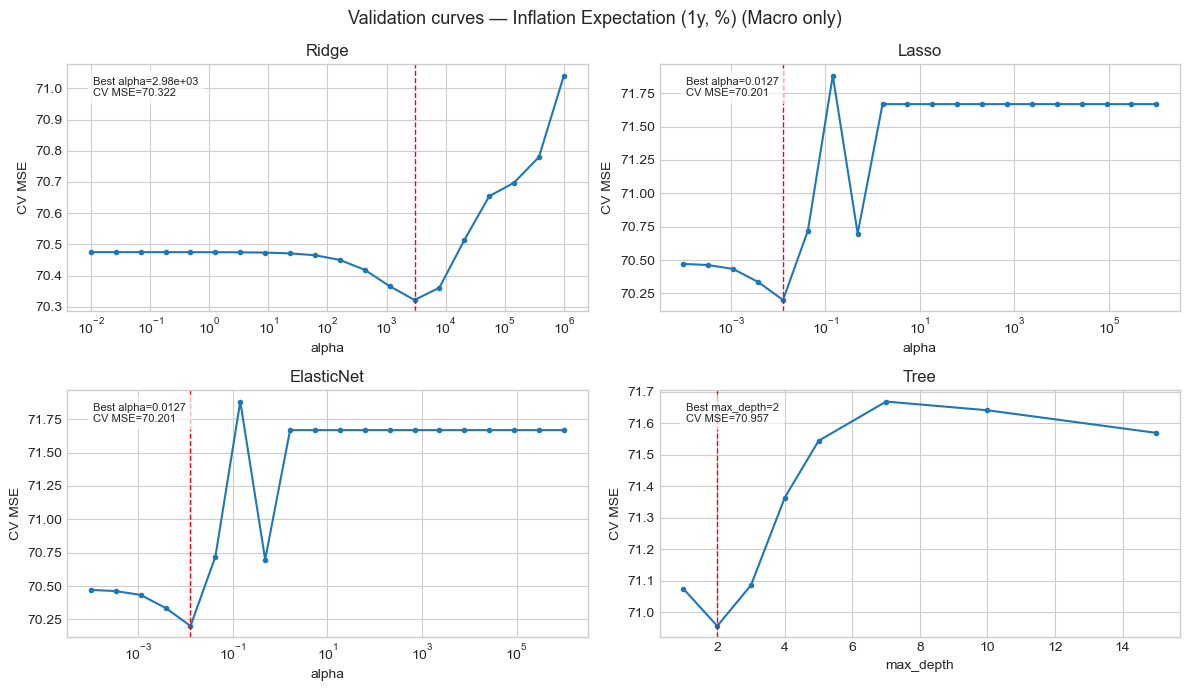

In [39]:
# Initialize result storing structures
all_metrics = []
macro_only_results = {}
# Initialize numerical and categorical feature lists for the "Macro only" feature set
num, cat = FEATURE_SETS["Macro only"]

# Choose which target to model
target = "infl_1y"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro only")
macro_only_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro only"))

### Comment on CV curves and optimal choice for each model (briefly)

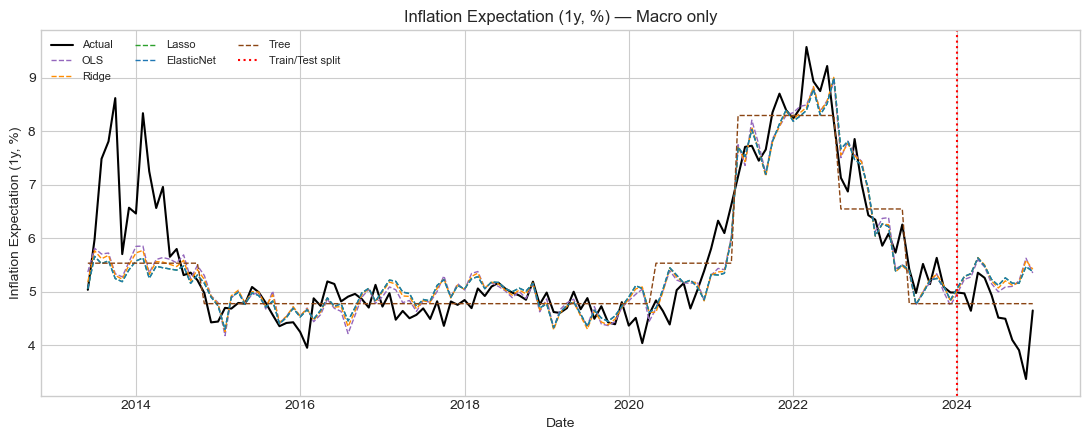

In [40]:
plot_predictions(res, train, test, target, num, cat, "Macro only")

### Comment on this time-series plot


── house_price_change (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=2.069e+04                      CV MSE=58.2148
  Lasso       alpha=0.1438                         CV MSE=58.5585
  ElasticNet  alpha=0.1438, l1_ratio=0.01          CV MSE=58.2118
  Tree        max_depth=1                          CV MSE=60.3531


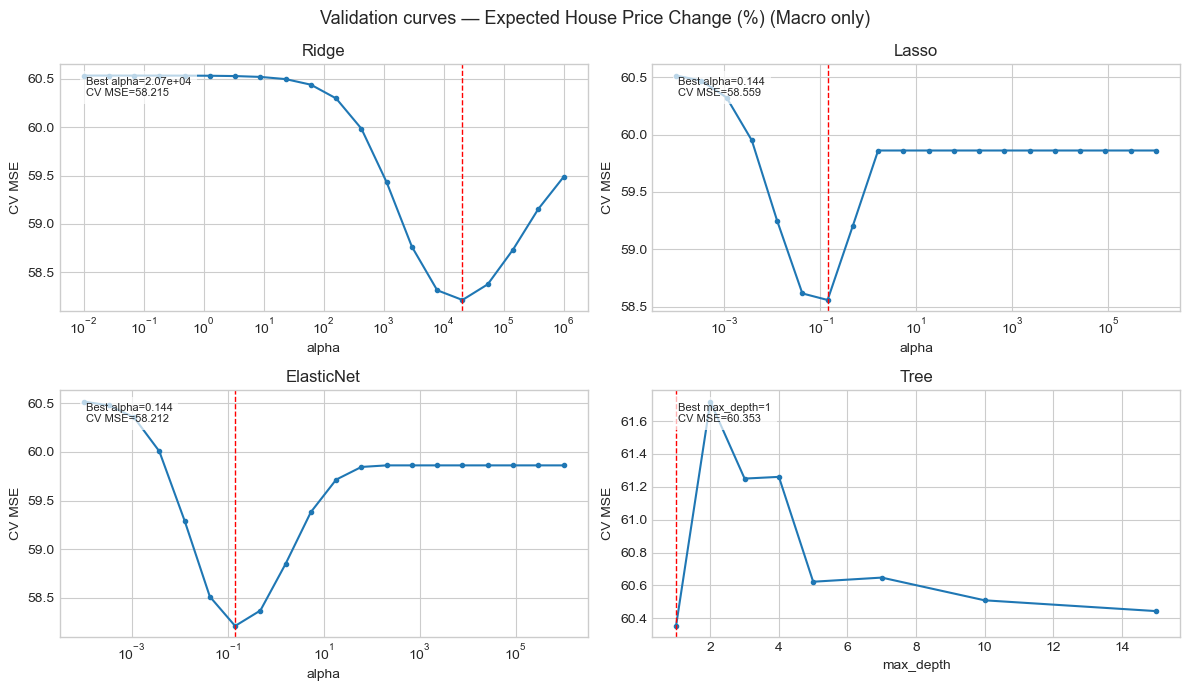

In [41]:
# Choose which target to model
target = "house_price_change"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro only")
macro_only_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro only"))

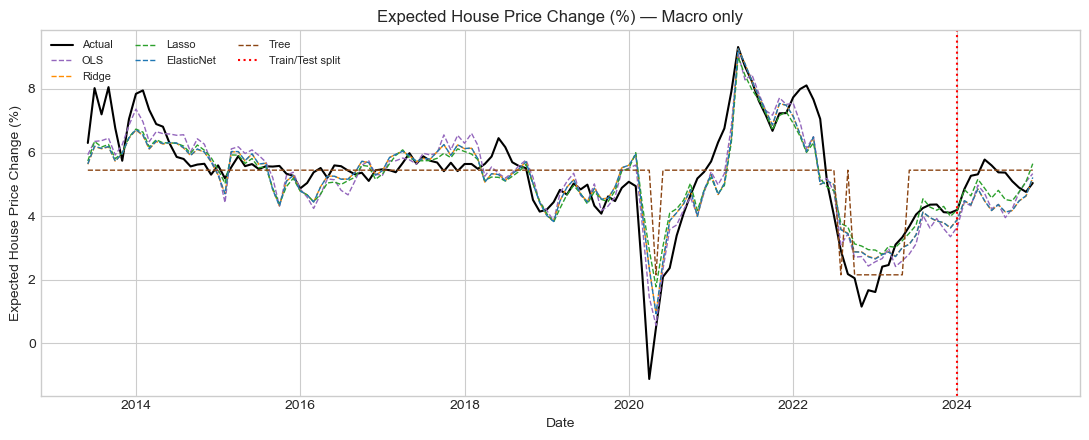

In [42]:
plot_predictions(res, train, test, target, num, cat, "Macro only")


── prob_unrate_up (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=3.793e+05                      CV MSE=491.1653
  Lasso       alpha=0.4833                         CV MSE=491.9245
  ElasticNet  alpha=0.4833, l1_ratio=0.25          CV MSE=490.9726
  Tree        max_depth=2                          CV MSE=499.6141


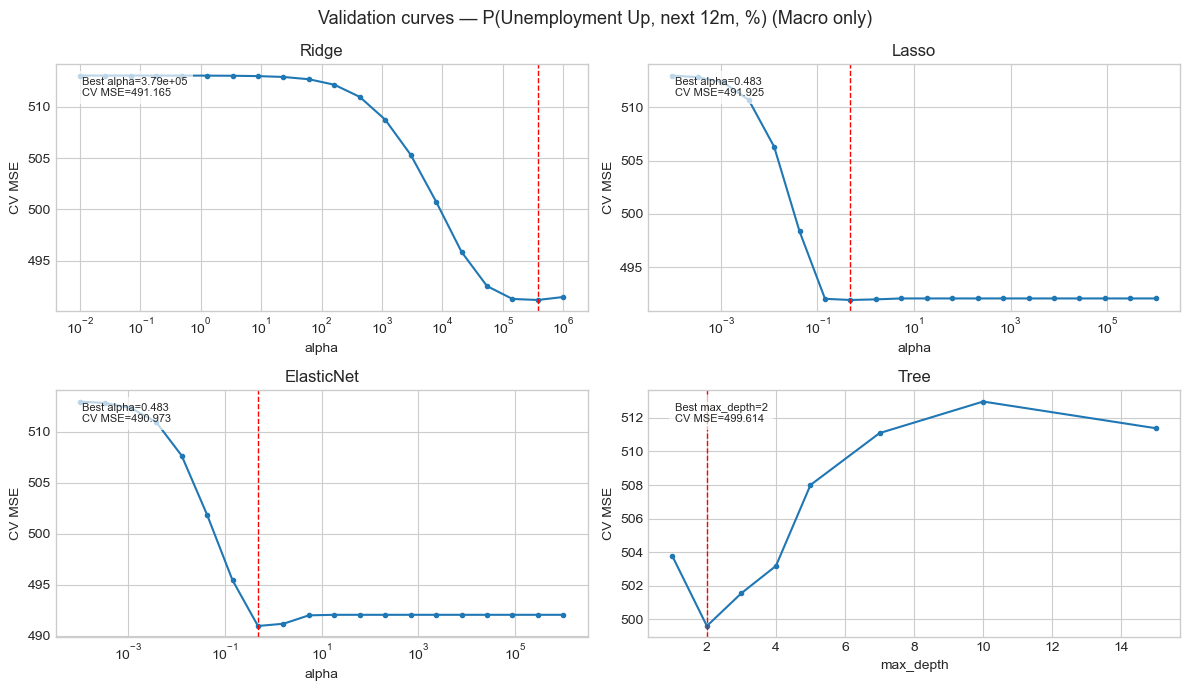

In [43]:
# Choose which target to model
target = "prob_unrate_up"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro only")
macro_only_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro only"))

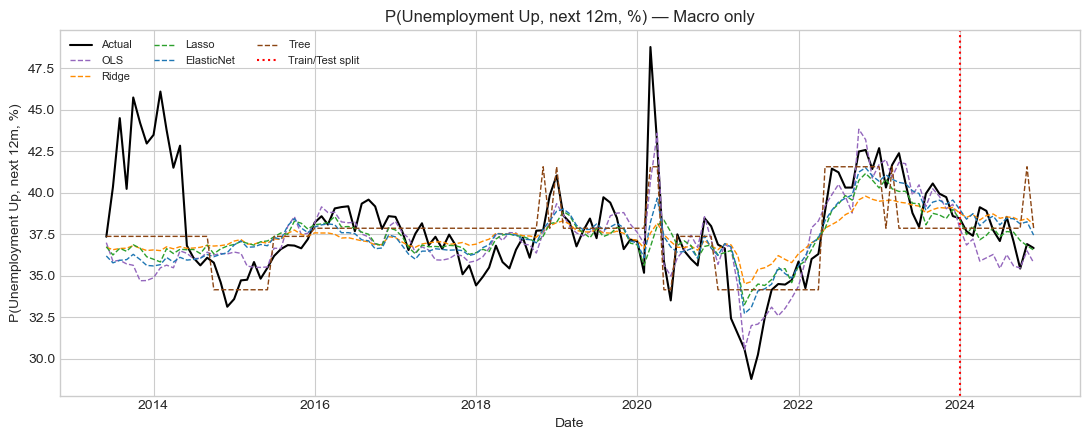

In [44]:
plot_predictions(res, train, test, target, num, cat, "Macro only")


── prob_stocks_up (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=1.438e+05                      CV MSE=491.2109
  Lasso       alpha=0.1438                         CV MSE=492.7156
  ElasticNet  alpha=1.624, l1_ratio=0.01           CV MSE=491.2610
  Tree        max_depth=1                          CV MSE=492.9585


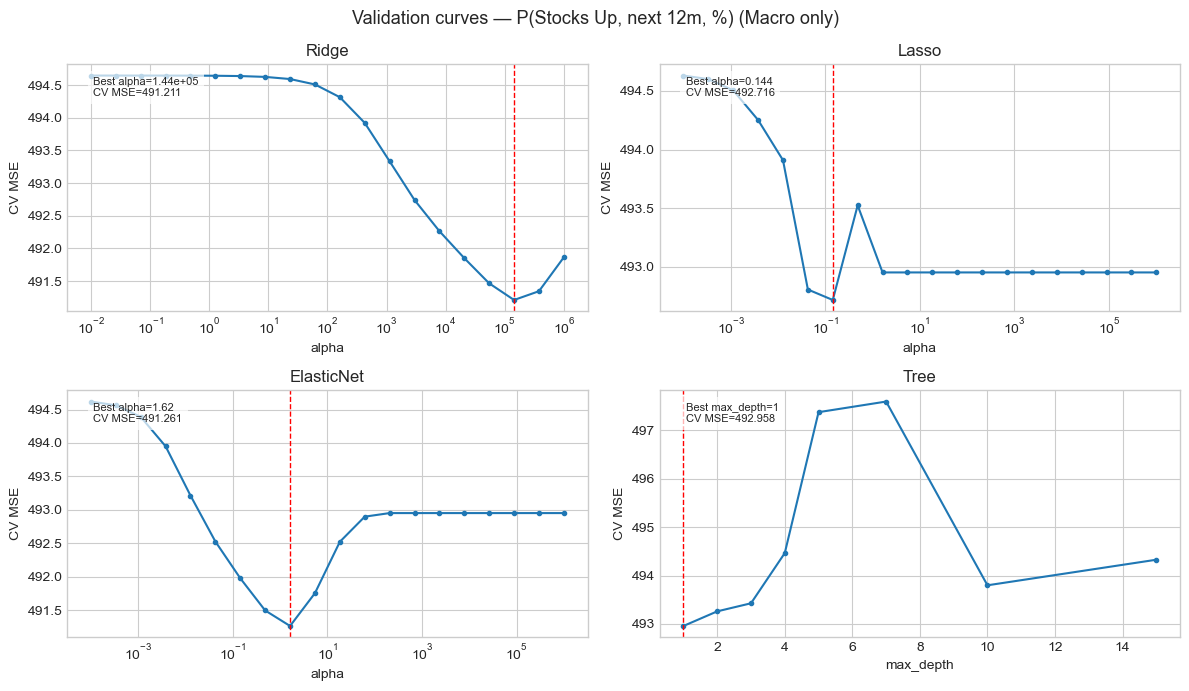

In [45]:
# Choose which target to model
target = "prob_stocks_up"

# Run CV, store results and compute test metrics for the "Macro only" feature set
res = run_cv_for_target(train, target, num, cat, "Macro only")
macro_only_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro only"))

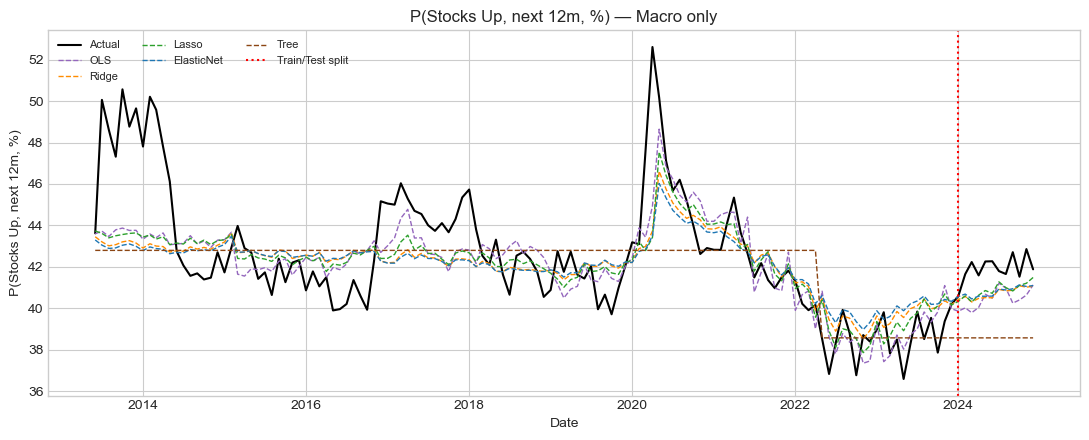

In [46]:
plot_predictions(res, train, test, target, num, cat, "Macro only")

### 5.1 - Only Macro/Finance Predictors

**infl_1y**:
- Ridge selects a large optimal α (≈ 2,980), indicating that heavy regularization is needed and that the macro features have limited predictive signal individually. The validation curve is U-shaped with a clear minimum, suggesting the search range is appropriate. Lasso selects a small α (≈ 0.013), retaining most features. ElasticNet also selects a small α with l1_ratio equal to 1, meaning it is identical to Lasso and adds no value to the analysis of this variable. The Decision Tree prefers a shallow depth of 2, consistent with low signal-to-noise in the data.
- With macro/finance features only, all linear models (OLS, Ridge, Lasso, ElasticNet) produce nearly identical predictions that track the broad trend in inflation expectations — capturing the rise from 2020 to the 2022 peak and subsequent decline — but fail to capture month-to-month variation. The Decision Tree produces a step-function pattern due to its piecewise constant nature. On the test sample (2024), all models overestimate inflation expectations as the actual series declines sharply while predictions remain elevated. This is reflected in negative R² values for all models on the test set.

**house_price_change**:
- Ridge selects a very large optimal α (≈ 20,700), suggesting near-complete shrinkage of coefficients and very weak macro signal. The validation curve shows a clear U-shape with a well-defined minimum. Lasso selects α ≈ 0.144 with a clear minimum, while ElasticNet selects the same α with l1_ratio = 0.01 — effectively behaving as Ridge rather than Lasso for this target. The Decision Tree prefers depth 1, meaning a single split on one macro variable captures the most predictive structure available.
- The linear models track the broad level of house price expectations reasonably well during stable periods but fail to capture the sharp COVID-19 collapse in early 2020 and the subsequent rapid recovery. The Decision Tree again produces a step-function pattern, missing the 2020 shock entirely. On the test sample (2024), the linear models perform somewhat better than for infl_1y, partially tracking the modest decline in house price expectations, though they still produce negative R² values. Notably, none of the models anticipate the sharp trough in 2020, which is an extreme event unlikely to be captured by a model trained on the preceding period.

**prob_unrate_up**: 
- Ridge selects an extremely large α (≈ 379,000), with the validation curve monotonically decreasing across the search range — suggesting the model is essentially shrinking all coefficients to near zero and predicting close to the mean. Lasso selects α ≈ 0.483 with a flat plateau for large α values, indicating that a sparse solution with few active features is sufficient. ElasticNet selects α ≈ 1.62 with l1_ratio = 0.25, combining both penalties. The Decision Tree prefers depth 2, with MSE rising sharply for deeper trees — a clear sign of overfitting with only macro features available.
- All models struggle to track prob_unrate_up with macro features only. The linear models produce predictions close to the sample mean throughout the training period, missing both the elevated readings in 2013–2014 and the sharp COVID-19 spike in early 2020. The Decision Tree captures some step-like variation but also misses the 2020 shock. On the test sample (2024), predictions are relatively stable around 37–38% while the actual series shows more variation. This is consistent with the near-zero correlations between macro variables and this target observed in Part 4, and reflected in the near-zero or negative R² values on the test set.

**prob_stocks_up**:
- Ridge again selects a very large α (≈ 144,000), consistent with the pattern seen for prob_unrate_up — macro features alone provide little signal and heavy shrinkage is optimal. Lasso and ElasticNet both select α ≈ 0.144, with ElasticNet using l1_ratio = 0.01, effectively behaving as Ridge for this target. The Decision Tree prefers depth 1, meaning a single macro variable split captures all available structure. CV MSE differences across models are small (491–493), confirming that no model has a meaningful advantage with macro features only.
- With macro features only, all models fail to track the pronounced downward trend in stock market optimism from ~50% in 2013 to ~38% by 2022–2023. The linear models produce relatively flat predictions around 42–43% throughout the training period, while the Decision Tree predicts a constant value of ~43%. Notably, none of the models capture the brief spike in stock market optimism during the COVID-19 recovery in 2020. On the test sample (2024), the linear models perform relatively well as the actual series stabilises around 41–42% — close to where the models predict — though this reflects the series mean rather than genuine predictive power. All models produce negative or near-zero R² on the test set.

### 5.2 - Macro/Finance Predictors + SCE Individual Predictors


── infl_1y (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=2976                           CV MSE=65.2556
  Lasso       alpha=0.01274                        CV MSE=65.1173
  ElasticNet  alpha=0.01274, l1_ratio=1            CV MSE=65.1173
  Tree        max_depth=5                          CV MSE=66.9706


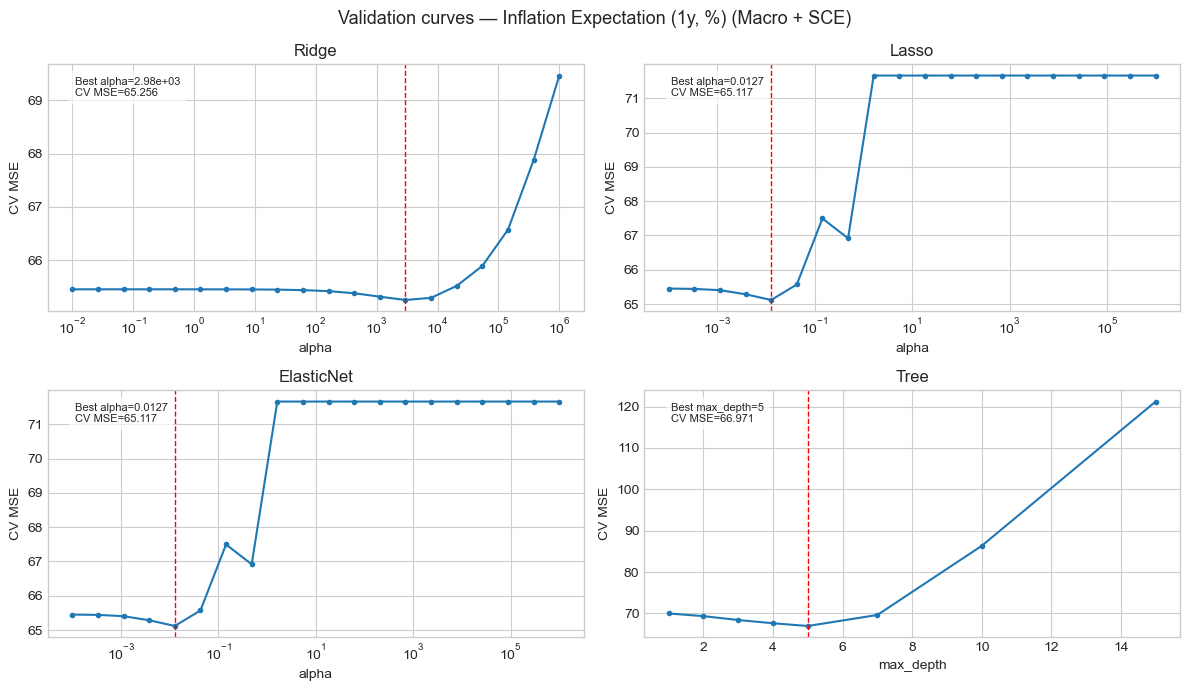

In [47]:
# Step 2: Macro + SCE
# New feature set
num, cat = FEATURE_SETS["Macro + SCE"]

# Initialize result storing structure for Macro + SCE
macro_sce_results = {}

# Choose which target to model
target = "infl_1y"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE")
macro_sce_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro + SCE"))

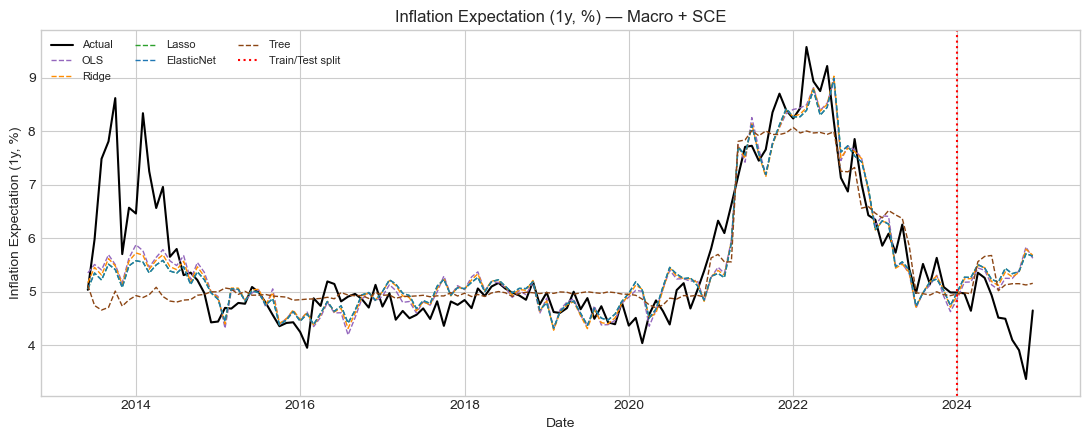

In [48]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE")


── house_price_change (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=2.069e+04                      CV MSE=55.5864
  Lasso       alpha=0.04281                        CV MSE=55.9974
  ElasticNet  alpha=0.1438, l1_ratio=0.01          CV MSE=55.5736
  Tree        max_depth=3                          CV MSE=58.6121


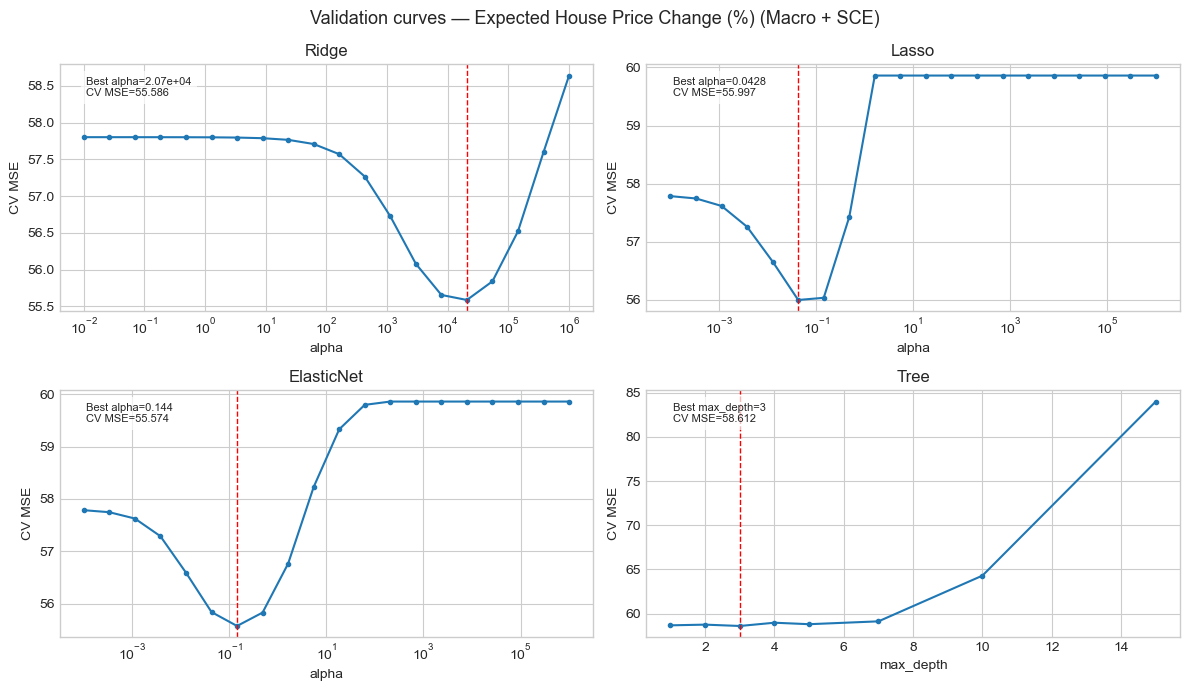

In [49]:
# Choose which target to model
target = "house_price_change"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE")
macro_sce_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro + SCE"))

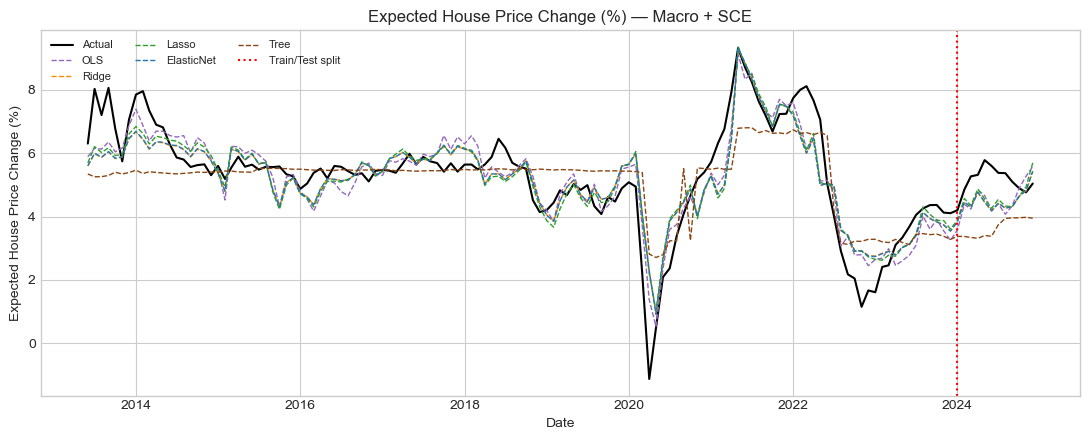

In [50]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE")


── prob_unrate_up (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=1.438e+05                      CV MSE=489.3213
  Lasso       alpha=0.4833                         CV MSE=490.6624
  ElasticNet  alpha=0.4833, l1_ratio=0.25          CV MSE=489.1502
  Tree        max_depth=3                          CV MSE=502.1113


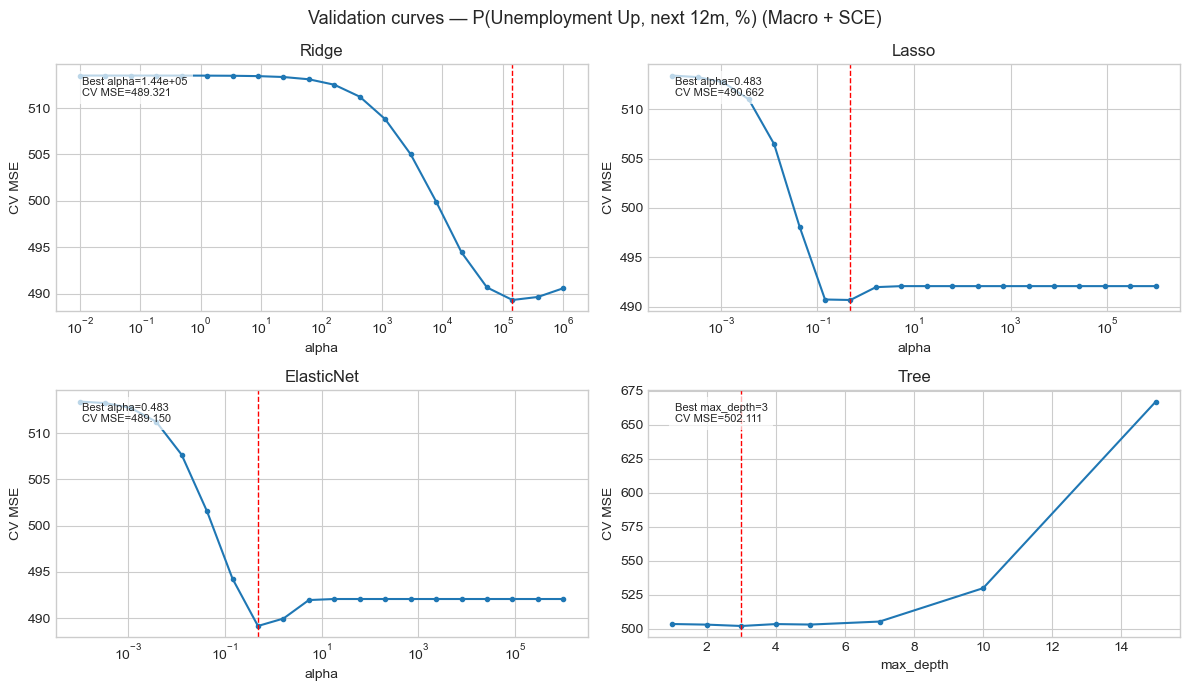

In [51]:
# Choose which target to model
target = "prob_unrate_up"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE")
macro_sce_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro + SCE"))

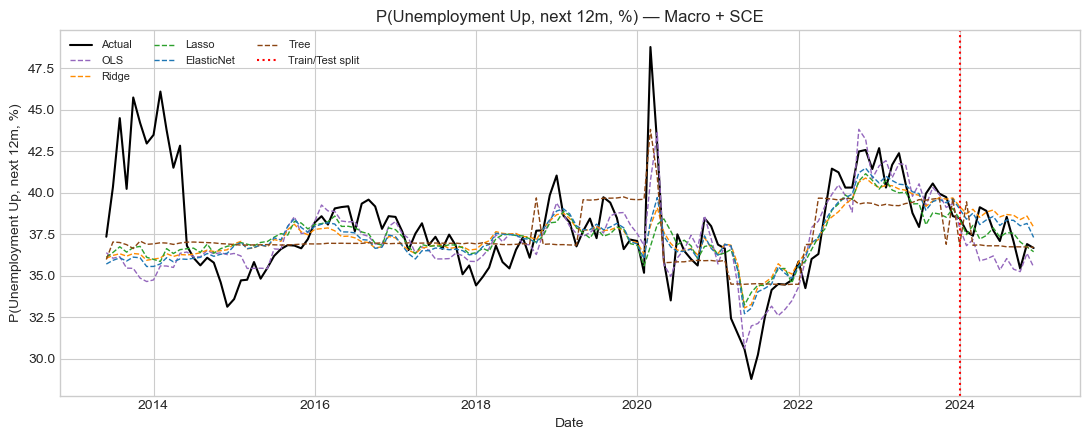

In [52]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE")


── prob_stocks_up (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=7848                           CV MSE=456.9652
  Lasso       alpha=0.1438                         CV MSE=456.9343
  ElasticNet  alpha=0.1438, l1_ratio=1             CV MSE=456.9343
  Tree        max_depth=4                          CV MSE=460.6942


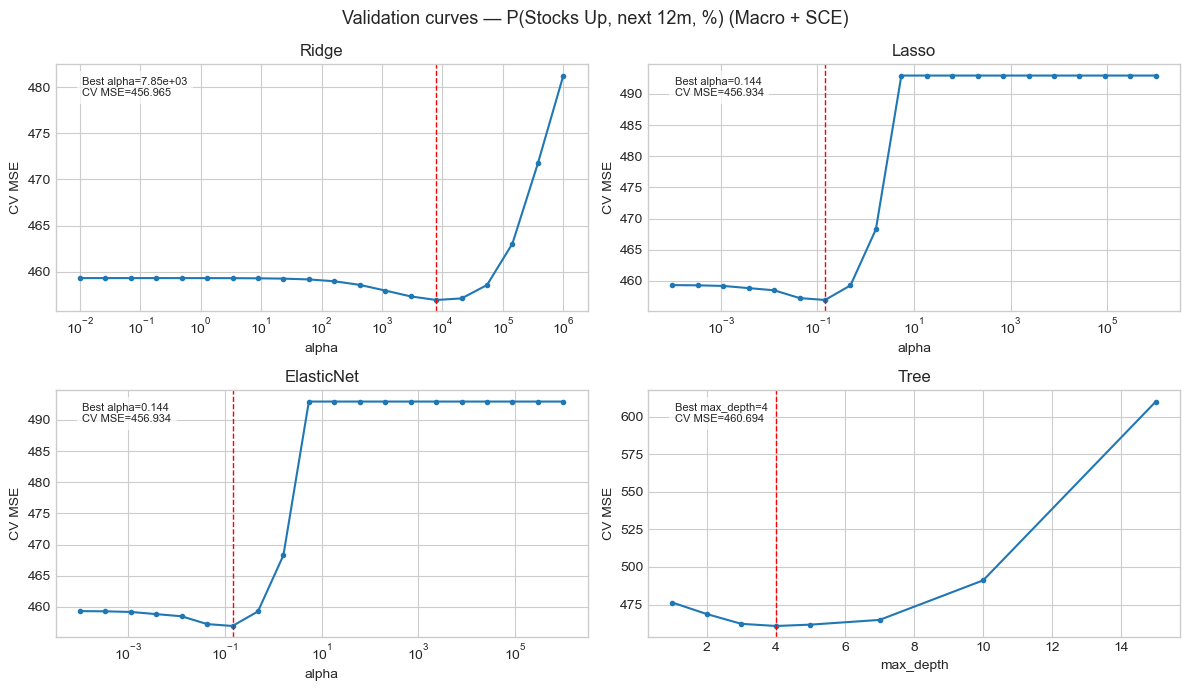

In [53]:
# Choose which target to model
target = "prob_stocks_up"

# Run CV, store results and compute test metrics for the "Macro + SCE" feature set
res = run_cv_for_target(train, target, num, cat, "Macro + SCE")
macro_sce_results[target] = res
all_metrics.append(test_metrics(res, test, target, num, cat, "Macro + SCE"))

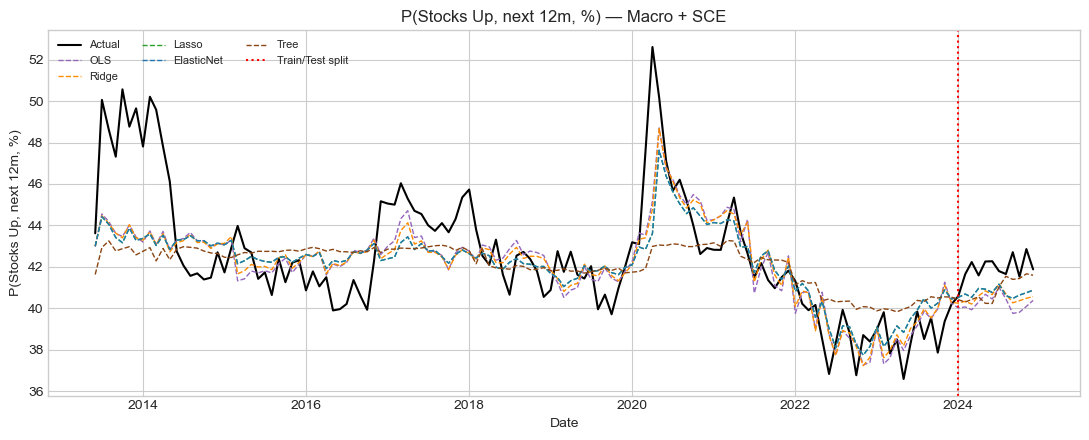

In [54]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE")

**infl_1y**:
- Adding SCE variables reduces CV MSE from ~70.3 to ~65.1–65.3 for linear models — a reduction of about 7%. Ridge retains the same optimal α (≈ 2,980) as in the macro-only case, suggesting the SCE variables do not change the regularization structure much. Lasso and ElasticNet both select small α values (≈ 0.013), retaining most features, but since Lasso picks l1_ratio at 1, these two models are identical for this target. The Decision Tree now prefers depth 5 compared to depth 2 in the macro-only case, reflecting that the additional SCE features provide more useful splits — though the steep rise in CV MSE for depths above 5 indicates clear overfitting risk.

- With SCE variables added, the predictions track the actual inflation expectations more closely, particularly during the low-inflation period 2015–2019 and the post-COVID surge in 2021–2022. The linear models show noticeably less bias compared to the macro-only case. The Decision Tree captures more variation in the training period but shows signs of overfitting — its predictions in 2022 are less smooth than the linear models. On the test sample (2024), all linear models overestimate inflation expectations as the actual series declines sharply, consistent with the modest R² of ~0.04. Overall, adding SCE variables leads to a meaningful improvement in fit but prediction of the sharp 2024 decline remains challenging.

**house_price_change**:
- Adding SCE variables reduces CV MSE from ~58.2 to ~55.6–55.9 for linear models — a reduction of about 4%. Ridge retains the same large optimal α (≈ 20,700), consistent with the macro-only case. Lasso selects a smaller α (≈ 0.043) compared to macro-only (0.144), suggesting that the additional SCE features require less aggressive shrinkage. ElasticNet selects α ≈ 0.144 with l1_ratio = 0.01, again behaving effectively as Ridge. The Decision Tree now prefers depth 3 rather than depth 1, and the steep rise in CV MSE for depths above 3 indicates strong overfitting risk with the expanded feature set.

- With SCE variables added, the linear models track the actual series noticeably better throughout the training period, particularly the gradual decline from 2013 to 2019 and the 2021–2022 surge. The COVID-19 collapse in early 2020 is partially captured by OLS, Lasso and ElasticNet — a clear improvement over the macro-only case where all models missed it entirely. The Decision Tree captures some step-like variation but underestimates the 2021–2022 peak and shows a downward drift from 2022 onward that diverges from the actual series. On the test sample (2024), linear models track the actual series reasonably well, consistent with the positive R² of ~0.039. Overall this represents a meaningful improvement over macro features alone.

**prob_unrate_up**: 
- Adding SCE variables reduces CV MSE marginally from ~491 to ~489 for Ridge and ElasticNet — a reduction of less than 1%, suggesting that individual-level variables add very little predictive power for unemployment expectations beyond what macro variables already capture. Ridge selects α ≈ 144,000, similar to the macro-only case. Lasso and ElasticNet both select α ≈ 0.483, consistent with macro-only. The Decision Tree validation curve rises sharply from depth 3 onward — CV MSE nearly doubles from ~500 at depth 3 to ~900 at depth 20 — indicating severe overfitting when SCE features are included.

- With SCE variables added, the linear models track the actual series somewhat better than in the macro-only case, particularly the gradual rise from 2021 to 2022 and the 2024 decline. OLS shows the most variation among the linear models, picking up some of the elevated readings in 2022. However, the 2020 COVID spike and the sharp trough in 2021 remain largely uncaptured. Improve this interpretation: (The Decision Tree predicts a constant level around 37–40% throughout, showing no improvement over the macro-only case despite the additional features — consistent with its high CV MSE). On the test sample (2024), linear models track the declining trend reasonably well, consistent with the positive R² of ~0.03. The SCE variables provide a modest but consistent improvement for this target.

**prob_stocks_up**:
- Adding SCE variables produces the largest CV MSE reduction of all four targets — from ~491–493 to ~457, a reduction of about 7%. Ridge selects a much smaller optimal α (≈ 7,848) compared to the macro-only case (≈ 144,000), indicating that the SCE variables provide genuine predictive signal that reduces the need for heavy regularization. Lasso and ElasticNet both select α ≈ 0.144 with l1_ratio = 1, collapsing to pure Lasso — the Ridge component adds no value for this target. The Decision Tree prefers depth 4, with CV MSE rising steeply beyond depth 7, indicating clear overfitting risk with the expanded feature set.

- With SCE variables added, predictions for prob_stocks_up improve substantially compared to the macro-only case. The linear models capture the long-run downward trend from ~50% in 2013 to ~38% in 2022–2023 much more closely, and partially track the COVID-19 recovery spike in 2020. OLS, Lasso and ElasticNet produce nearly identical predictions throughout, while Ridge is slightly smoother. The Decision Tree captures more variation in the training period but remains noisier than the linear models. On the test sample (2024), all models track the stabilisation around 41–42% well, consistent with the highest test R² among all four targets (OLS and Lasso: ~0.11, Tree: ~0.11). This strong improvement relative to macro-only suggests that demographic variables — particularly gender, education, and income rank — are meaningful predictors of stock market optimism, consistent with the literature on financial literacy and investment participation.


OVERALL COMMENT ON WHETHER ADDING VARIABLES IMPROVES THE PREDICTION MODELS

In [55]:
# Display results
results_df = pd.concat(all_metrics, ignore_index=True)
display(results_df.pivot_table(
    index=['target', 'feature_set'],
    columns='model',
    values=['RMSE', 'R2']
).round(4))

R2                                  \
model                          ElasticNet   Lasso     OLS   Ridge    Tree   
target             feature_set                                              
house_price_change Macro + SCE     0.0432  0.0444  0.0432  0.0431 -0.0142   
                   Macro only     -0.0078 -0.0025 -0.0077 -0.0079 -0.0014   
infl_1y            Macro + SCE     0.0497  0.0497  0.0501  0.0496  0.0407   
                   Macro only     -0.0053 -0.0053 -0.0053 -0.0056 -0.0003   
prob_stocks_up     Macro + SCE     0.1185  0.1185  0.1187  0.1181  0.1148   
                   Macro only     -0.0024 -0.0021 -0.0042 -0.0027 -0.0210   
prob_unrate_up     Macro + SCE     0.0297  0.0241  0.0353  0.0247  0.0266   
                   Macro only     -0.0008  0.0003 -0.0035 -0.0014 -0.0033   

                                     RMSE                                      
model                          ElasticNet    Lasso      OLS    Ridge     Tree  
target             feature_set                                                 
house_price_change Macro + SCE     8.2553   8.2504   8.2555   8.2558   8.4996  
                   Macro only      8.4728   8.4505   8.4721   8.4730   8.4457  
infl_1y            Macro + SCE     8.9990   8.9990   8.9970   8.9994   9.0415  
                   Macro only      9.2557   9.2557   9.2558   9.2571   9.2328  
prob_stocks_up     Macro + SCE    21.5527  21.5527  21.5498  21.5572  21.5972  
                   Macro only     22.9826  22.9795  23.0038  22.9864  23.1955  
prob_unrate_up     Macro + SCE    21.9871  22.0508  21.9240  22.0444  22.0226  
                   Macro only     22.3307  22.3183  22.3601  22.3365  22.3584

DOUBLE-CHECK VALUES BELOW

Including individual-level SCE variables leads to a consistent improvement across all four targets. For infl_1y, test R² increases from essentially zero (macro only) to 0.050 with OLS. For house_price_change, R² rises from negative to 0.044 with Lasso. For prob_unrate_up, the improvement is modest — R² increases to 0.035 with OLS — consistent with the near-zero SCE correlations observed in Part 4. The largest improvement is for prob_stocks_up, where R² rises from negative to 0.119 with OLS, driven by the strong predictive power of gender, education, income rank and financial literacy. However, absolute R² values remain low across all targets, indicating that a large share of individual-level variation in expectations cannot be captured by macro/finance variables or stable demographic characteristics alone.

NOTE THAT DIFFERENCE IN PERFORMANCE IS VERY VERY SMALL - PICKING THE BEST MODEL IS BASICALLY USELESS OR SOMETHING :::

In [56]:
# Summarize best models by R² and RMSE
summary = []
for target in TARGETS:
    target_df = results_df[results_df["target"] == target]
    best_r2_row = target_df.loc[target_df["R2"].idxmax()]
    best_rmse_row = target_df.loc[target_df["RMSE"].idxmin()]
    summary.append({
        "target": target,
        "best_R2_model": best_r2_row["model"],
        "best_R2": best_r2_row["R2"],
        "best_R2_feature_set": best_r2_row["feature_set"],
        "best_RMSE_model": best_rmse_row["model"],
        "best_RMSE": best_rmse_row["RMSE"],
        "best_RMSE_feature_set": best_rmse_row["feature_set"],
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

,target,best_R2_model,best_R2,best_R2_feature_set,best_RMSE_model,best_RMSE,best_RMSE_feature_set
0,infl_1y,OLS,0.050128,Macro + SCE,OLS,8.997028,Macro + SCE
1,house_price_change,Lasso,0.044370,Macro + SCE,Lasso,8.250429,Macro + SCE
2,prob_unrate_up,OLS,0.035290,Macro + SCE,OLS,21.923992,Macro + SCE
3,prob_stocks_up,OLS,0.118698,Macro + SCE,OLS,21.549830,Macro + SCE


The best-performing feature set is consistently Macro + SCE across all targets and metrics. Among models, OLS performs best or near-best for three of four targets, suggesting the relationship between features and expectations is approximately linear and that regularization provides limited additional benefit given the large sample size. prob_stocks_up stands out as the most predictable target with R² = 0.119, while prob_unrate_up and house_price_change remain the hardest to predict.

NOTE AGAIN THAT DIFFERENCES IN PERFORMANCE ARE VERY VERY SMALL

## Part 6 - Predict Optimism Indicators (Categorizing)

In [57]:
# Correlations for predictor choice - Macro/Finance
html_tables = []
for col in OPTIMISM_COLS:
    corr = (
        sce_data[MACRO_COLS]
        .corrwith(sce_data[col])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.20)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {col}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
sp500_chg12m,0.07
mortgage_30y,-0.06
federal_funds,-0.05
federal_funds_chg12m,-0.05
10y_yield,-0.05
unemployment,0.05
mortgage_30y_chg12m,-0.04
wti_crude_oil_chg12m,0.04
usd_index,-0.04
usd_index_chg12m,-0.04


In [58]:
# Correlations for predictor choice - SCE predictors
html_tables = []
for col in OPTIMISM_COLS:
    corr = (
        sce_data[COLS_FIRST_WAVE + COLS_INDIVIDUAL]
        .corrwith(sce_data[col])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.20)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {col}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
num_lit_q2_correct,-0.07
num_lit_q3_correct,-0.05
educ,-0.05
num_lit_q6_correct,-0.05
female,0.04
age_init,0.03
num_lit_q5_correct,-0.03
num_lit_q1_correct,-0.03
hh_inc_bin_rank,-0.03
hispanic,0.02


In [59]:

NUM_MACRO_OPT = [
    'house_price_idx', 'cpi_chg12m', 'usd_index_chg12m', 'real_gdp', 
    'vix', 'unemployment', 'sp500_chg12m', 'federal_funds_chg12m', 'mortgage_30y_chg12m'
]

NUM_SCE_OPT = [
    'num_lit_q2_correct', 'num_lit_q3_correct', 
    "female", "black", "hh_inc_bin_rank", "working"
]

ENCODE_SCE_OPT = [
    "educ"
]

FEATURE_SETS_OPT = {
    "Macro only":  (NUM_MACRO_OPT,            []),
    "Macro + SCE": (NUM_MACRO_OPT + NUM_SCE_OPT,  ENCODE_SCE_OPT)
}


OPT_TARGETS = OPTIMISM_COLS
OPT_TARGET_LABELS = {
    "optimist_unrate":      "Unemployment Optimists (prob < 50%)",
    "optimist_stocks":      "Stock Market Optimists (prob > 50%)",
    "optimist_house_price": "House Price Optimists (change > 0%)",
}

# Configuration for the "Optimism" models (Overwrite)
MODELS = {
    # Logistic regression
    "LogisticRegression": {
        "estimator": LogisticRegression(random_state=0, max_iter=5000),
        "param_grid": {"estimator__C": np.logspace(-4, 4, 20)},
        "scale": True,
        "param_name": "estimator__C",
        "log_x": True,
    },
    # Random forest classifier
    "RandomForest": {
        "estimator": RandomForestClassifier(random_state=0),
        "param_grid": {"estimator__max_depth": [1, 2, 3, 5, 7, 10, None]},
        "scale": False,
        "param_name": "estimator__max_depth",
        "log_x": False,
    },
    # Histogram-based gradient boosting classifier
    "HistGradientBoosting": {
        "estimator": HistGradientBoostingClassifier(random_state=0),
        "param_grid": {"estimator__max_depth": [1, 2, 3, 5, 7, 10, None]},
        "scale": False,
        "param_name": "estimator__max_depth",
        "log_x": False,
    },
}

COLORS = {
    "LogisticRegression": "tab:blue",
    "RandomForest": "tab:green",
    "HistGradientBoosting": "tab:orange",
}

In [60]:
# ── Compute test metrics for classification models ─────────────────────────────
def test_metrics_clf(results, test, target, num_cols, cat_cols, feature_set_name):
    """
    Classification metrics per model on the test sample.

    Parameters
    ----------
    results : dict
        Mapping model_name -> {"pipeline": fitted_pipeline, ...}
    test : pd.DataFrame
        Test DataFrame containing features and the binary target.
    target : str
        Name of the binary target column (0/1).
    num_cols, cat_cols : list[str]
        Lists of numeric and categorical feature names.
    feature_set_name : str
        Label for the feature set (e.g. "Macro", "Macro + SCE").

    Returns
    -------
    pd.DataFrame
        One row per model with Accuracy, Precision, Recall, F1, ROC-AUC.
        ROC-AUC is NaN if the model does not support predict_proba.
    """
    features = num_cols + cat_cols
    X_te = test[features]
    y_te = test[target].values

    rows = []
    for model_name, mr in results.items():
        pipe = mr["pipeline"]

        # hard predictions for accuracy / F1
        y_pred = pipe.predict(X_te)

        # probabilities for ROC-AUC if available
        roc_auc = np.nan
        if hasattr(pipe, "predict_proba"):
            y_prob = pipe.predict_proba(X_te)[:, 1]
            roc_auc = roc_auc_score(y_te, y_prob)

        rows.append({
            "feature_set": feature_set_name,
            "target": target,
            "model": model_name,
            "Accuracy":  accuracy_score(y_te, y_pred),
            "Precision": precision_score(y_te, y_pred, zero_division=0),
            "Recall":    recall_score(y_te, y_pred, zero_division=0),
            "F1":        f1_score(y_te, y_pred, zero_division=0),
            "ROC-AUC":   roc_auc,
        })

    return pd.DataFrame(rows)


── optimist_unrate (Macro) ──
  LogisticRegression C=0.0001                             CV ROC-AUC=0.5332
  RandomForest max_depth=1                          CV ROC-AUC=0.5347
  HistGradientBoosting max_depth=3                          CV ROC-AUC=0.5311


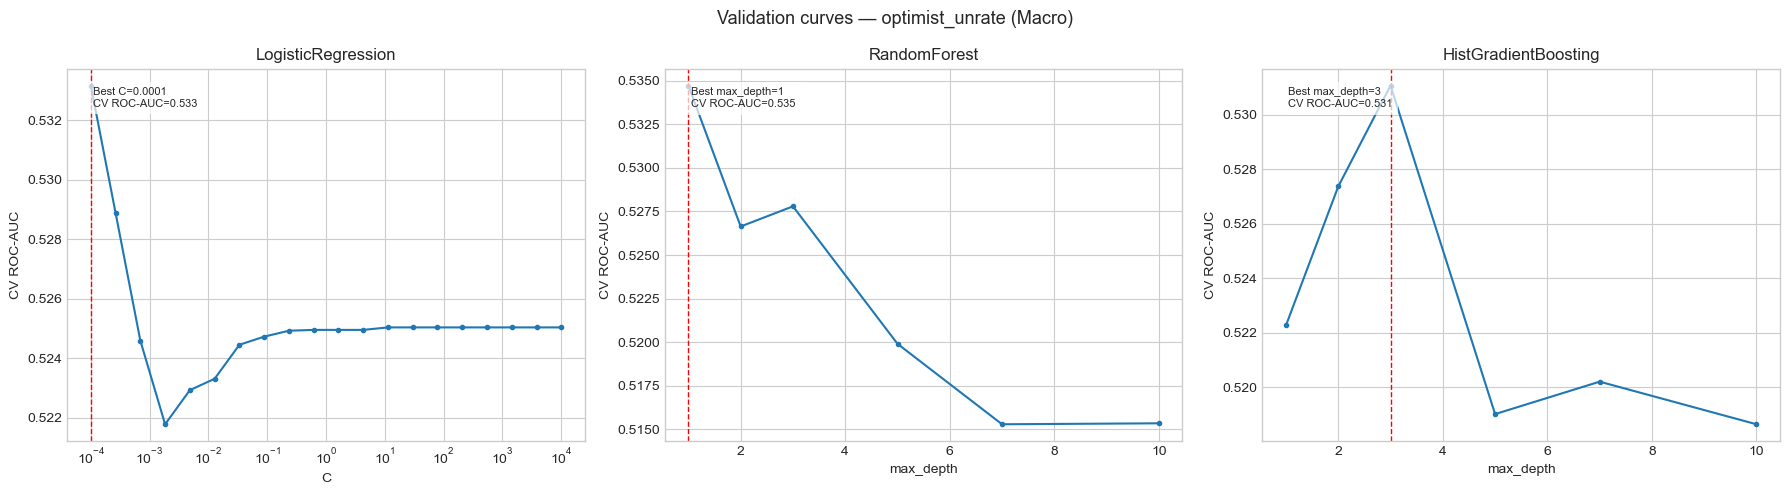

In [61]:
num, cat = FEATURE_SETS_OPT["Macro only"]
clf_metrics = []

target = "optimist_unrate"

res = run_cv_for_target(train, target, num, cat, "Macro", PART_6=True)
clf_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro"))

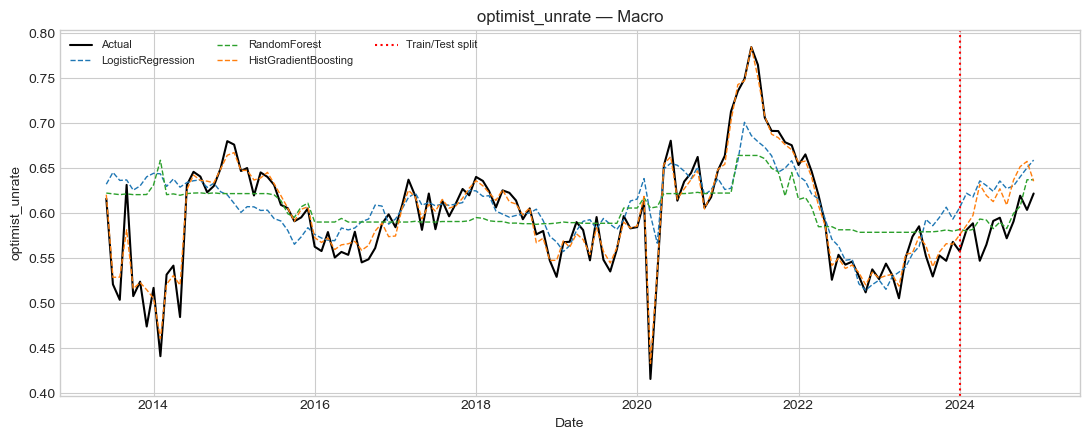

In [62]:
plot_predictions(res, train, test, target, num, cat, "Macro", split_date="2024-01-01")


── optimist_stocks (Macro) ──
  LogisticRegression C=1.624                              CV ROC-AUC=0.5081
  RandomForest max_depth=None                       CV ROC-AUC=0.4753
  HistGradientBoosting max_depth=7                          CV ROC-AUC=0.4912


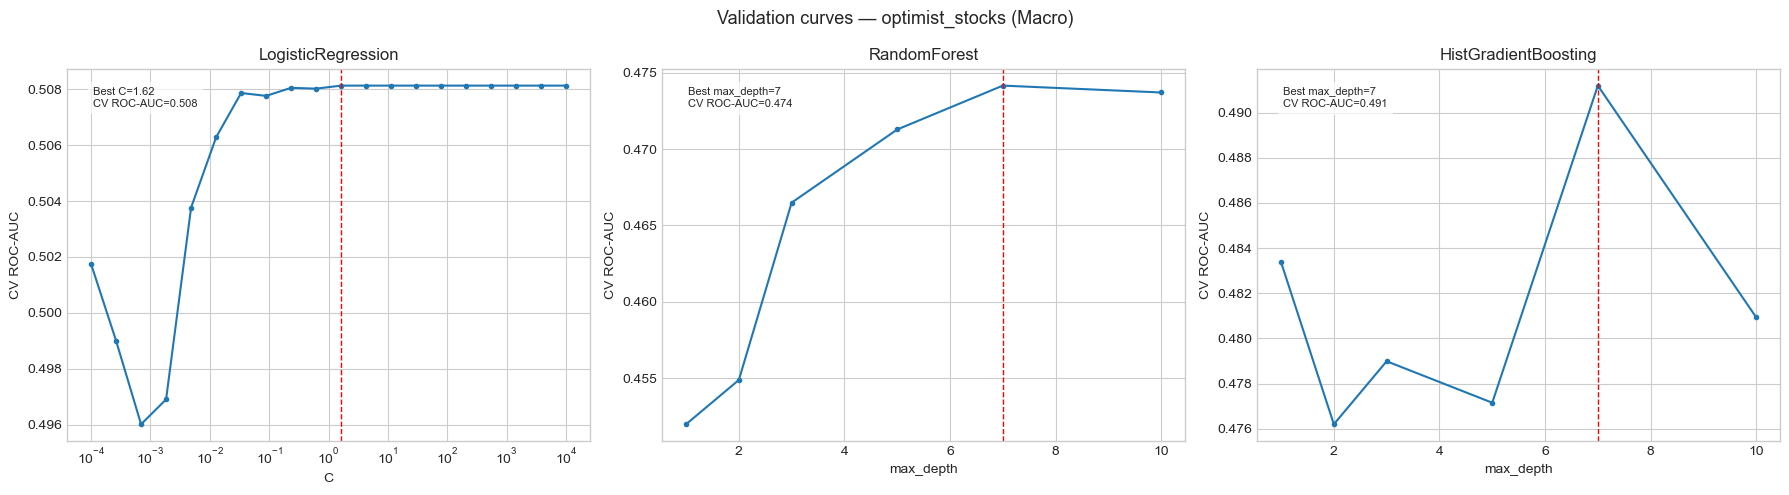

In [63]:
target = "optimist_stocks"

res = run_cv_for_target(train, target, num, cat, "Macro", PART_6=True)
clf_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro"))

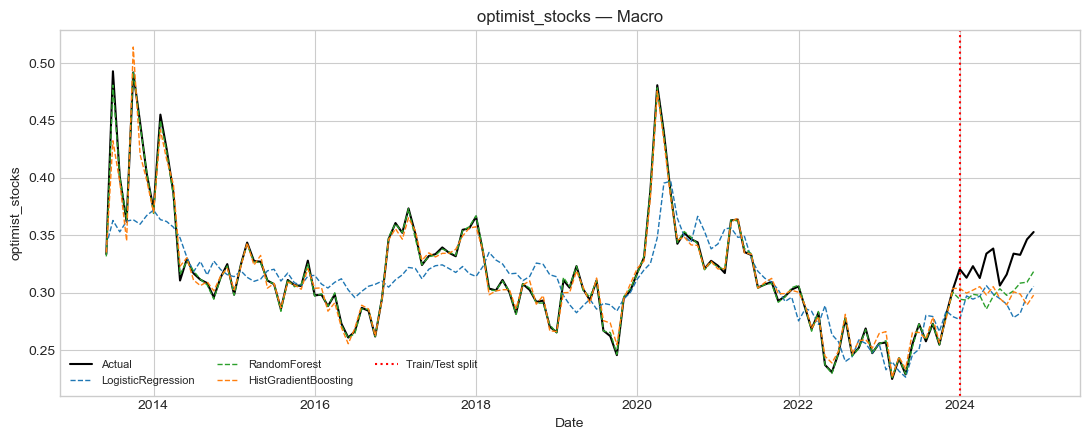

In [64]:
plot_predictions(res, train, test, target, num, cat, "Macro", split_date="2024-01-01")


── optimist_house_price (Macro) ──
  LogisticRegression C=0.0001                             CV ROC-AUC=0.3945
  RandomForest max_depth=1                          CV ROC-AUC=0.3146
  HistGradientBoosting max_depth=1                          CV ROC-AUC=0.2395


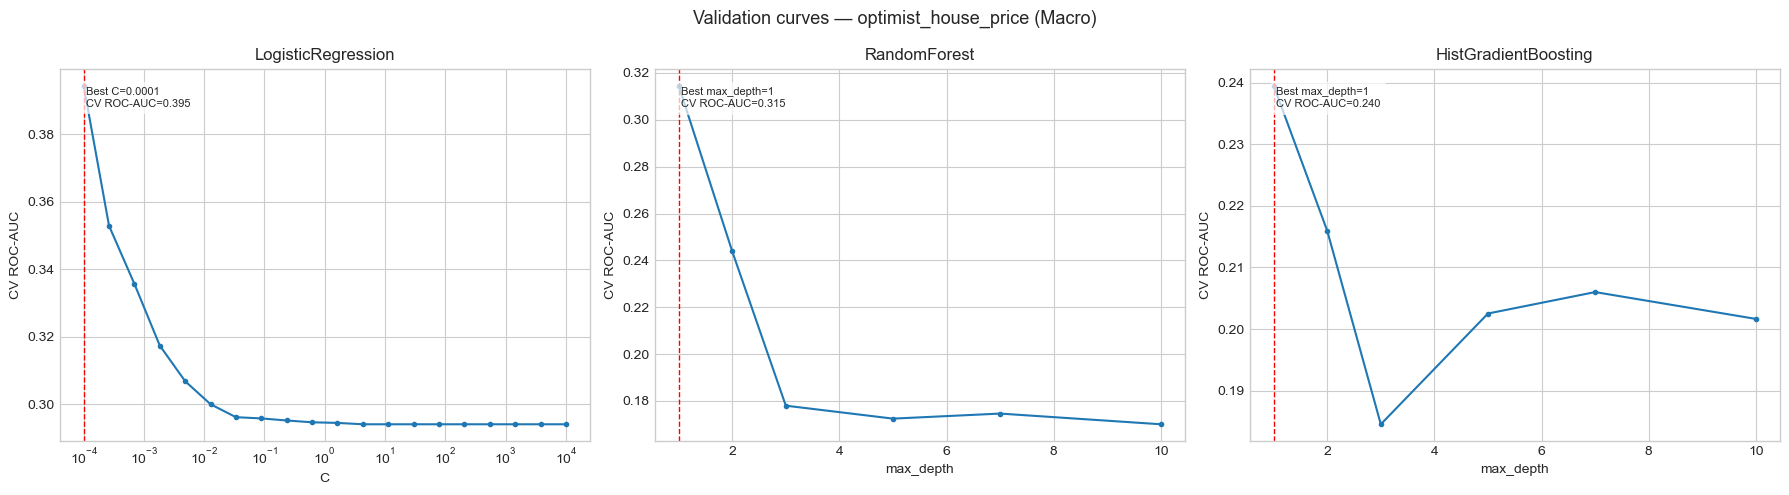

In [65]:
target = "optimist_house_price"

res = run_cv_for_target(train, target, num, cat, "Macro", PART_6=True)
clf_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro"))

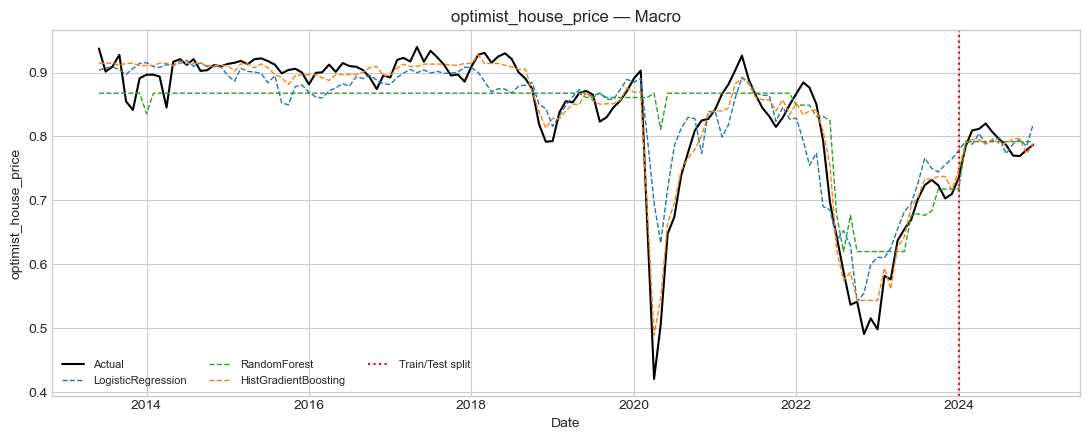

In [66]:
plot_predictions(res, train, test, target, num, cat, "Macro", split_date="2024-01-01")

### 6.2


── optimist_unrate (Macro + SCE) ──
  LogisticRegression C=0.0001                             CV ROC-AUC=0.5409
  RandomForest max_depth=1                          CV ROC-AUC=0.5378
  HistGradientBoosting max_depth=2                          CV ROC-AUC=0.5482


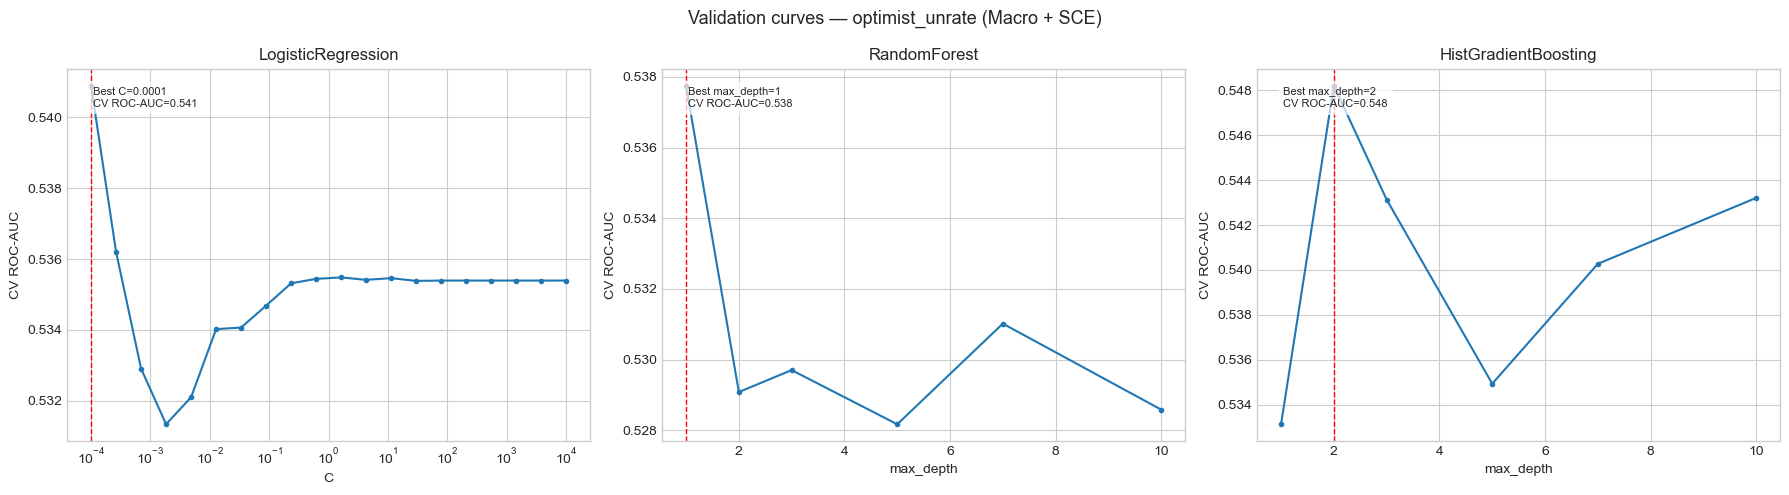

In [67]:
num, cat = FEATURE_SETS_OPT["Macro + SCE"]

target = "optimist_unrate"

res = run_cv_for_target(train, target, num, cat, "Macro + SCE", PART_6=True)
clf_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro + SCE"))

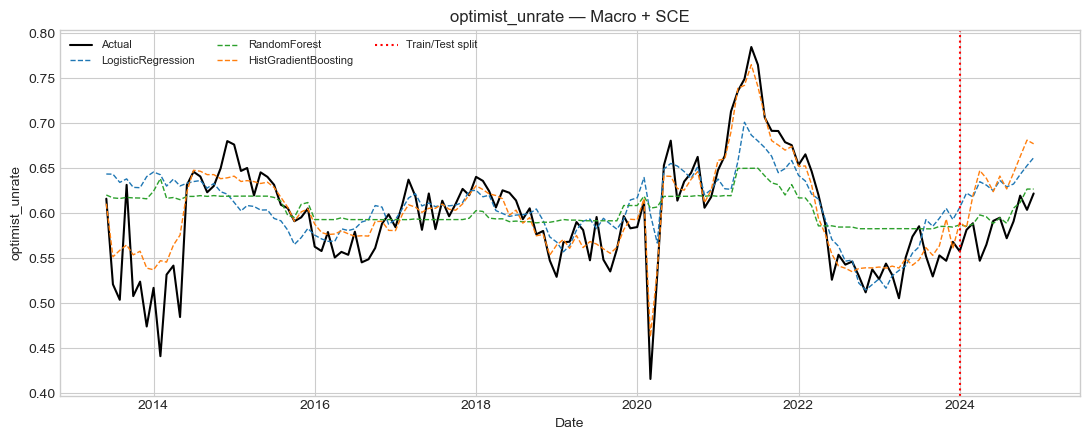

In [68]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE", split_date="2024-01-01")


── optimist_stocks (Macro + SCE) ──


/opt/anaconda3/envs/FIE463/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  LogisticRegression C=0.004833                           CV ROC-AUC=0.6215
  RandomForest max_depth=1                          CV ROC-AUC=0.5821
  HistGradientBoosting max_depth=1                          CV ROC-AUC=0.5749


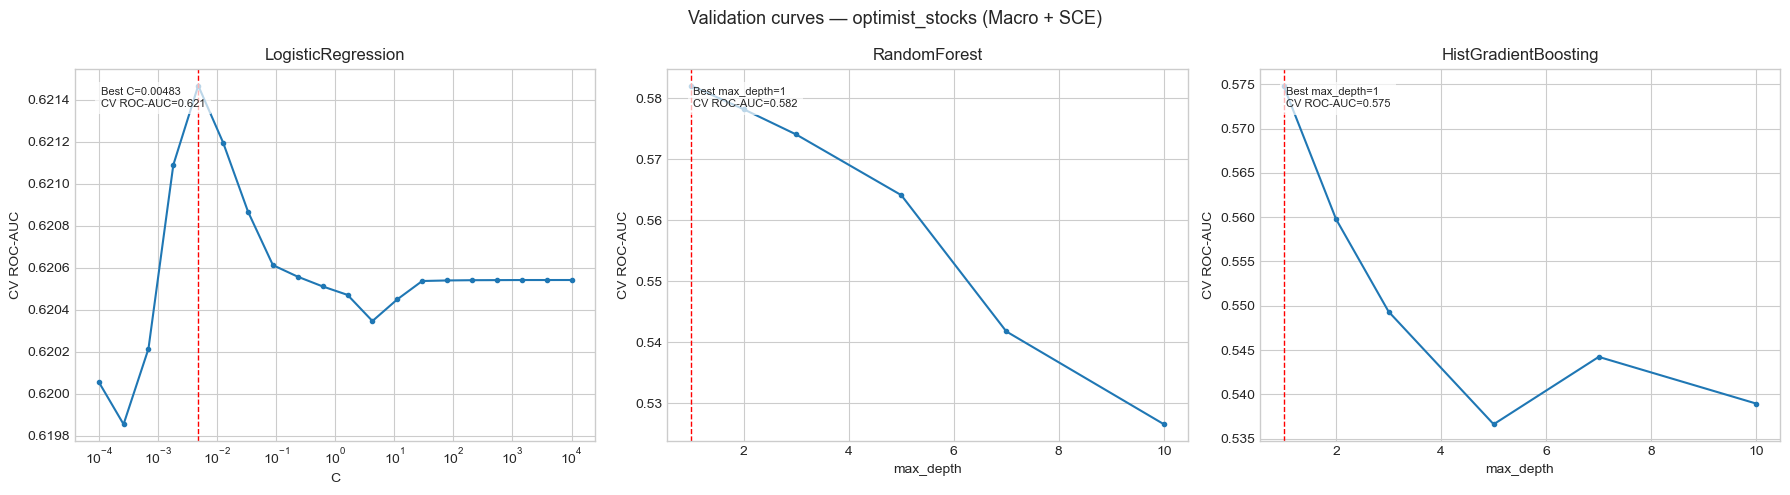

In [69]:
target = "optimist_stocks"

res = run_cv_for_target(train, target, num, cat, "Macro + SCE", PART_6=True)
clf_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro + SCE"))

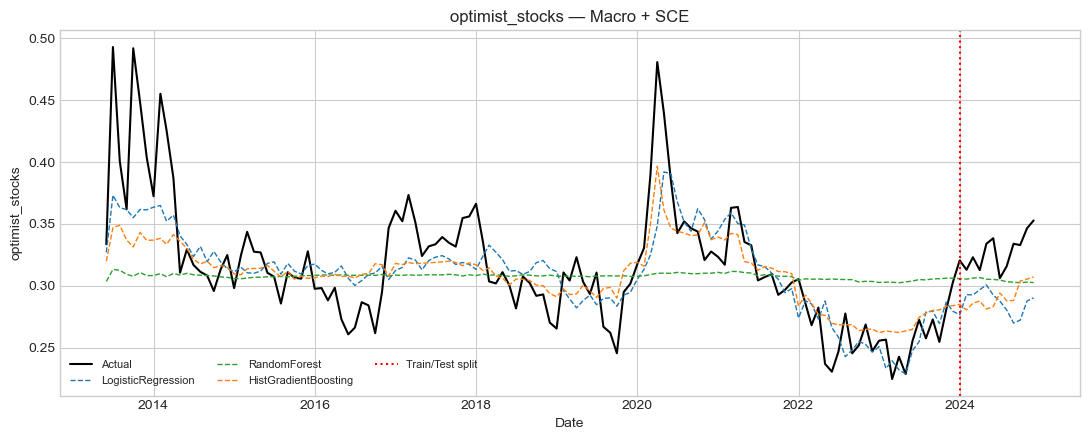

In [70]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE", split_date="2024-01-01")


── optimist_house_price (Macro + SCE) ──
  LogisticRegression C=0.0001                             CV ROC-AUC=0.3876
  RandomForest max_depth=1                          CV ROC-AUC=0.3082
  HistGradientBoosting max_depth=1                          CV ROC-AUC=0.2352


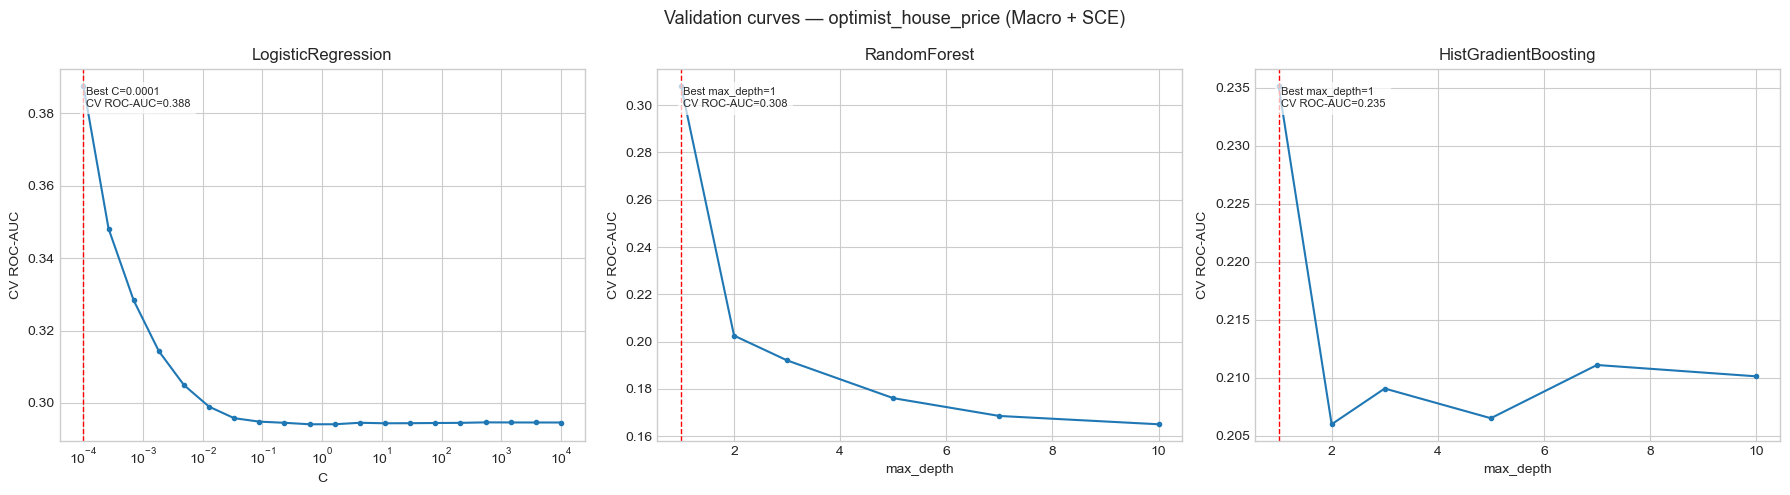

In [71]:
target = "optimist_house_price"

res = run_cv_for_target(train, target, num, cat, "Macro + SCE", PART_6=True)
clf_metrics.append(test_metrics_clf(res, test, target, num, cat, "Macro + SCE"))

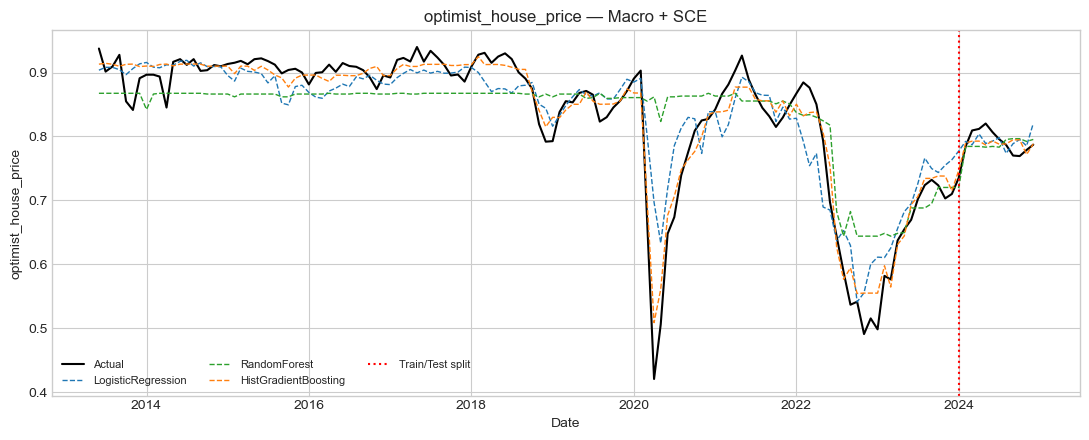

In [72]:
plot_predictions(res, train, test, target, num, cat, "Macro + SCE", split_date="2024-01-01")

In [73]:
# Display results
results_df = pd.concat(clf_metrics, ignore_index=True)
display(results_df.pivot_table(
    index=['target', 'feature_set'],
    columns='model',
    values=['Accuracy', 'F1', 'ROC-AUC']
).round(4))

Accuracy                     \
model                            HistGradientBoosting LogisticRegression   
target               feature_set                                           
optimist_house_price Macro                     0.7879             0.7879   
                     Macro + SCE               0.7879             0.7879   
optimist_stocks      Macro                     0.6731             0.6731   
                     Macro + SCE               0.6731             0.6731   
optimist_unrate      Macro                     0.5856             0.5856   
                     Macro + SCE               0.5874             0.5856   

                                                                F1  \
model                            RandomForest HistGradientBoosting   
target               feature_set                                     
optimist_house_price Macro             0.7879               0.8814   
                     Macro + SCE       0.7879               0.8814   
optimist_stocks      Macro             0.6731               0.0000   
                     Macro + SCE       0.6731               0.0000   
optimist_unrate      Macro             0.5856               0.7387   
                     Macro + SCE       0.5856               0.7388   

                                                                  \
model                            LogisticRegression RandomForest   
target               feature_set                                   
optimist_house_price Macro                   0.8814       0.8814   
                     Macro + SCE             0.8814       0.8814   
optimist_stocks      Macro                   0.0000       0.0000   
                     Macro + SCE             0.0000       0.0000   
optimist_unrate      Macro                   0.7387       0.7387   
                     Macro + SCE             0.7387       0.7387   

                                              ROC-AUC                     \
model                            HistGradientBoosting LogisticRegression   
target               feature_set                                           
optimist_house_price Macro                     0.5096             0.5147   
                     Macro + SCE               0.5209             0.5214   
optimist_stocks      Macro                     0.4972             0.5071   
                     Macro + SCE               0.6864             0.6856   
optimist_unrate      Macro                     0.5139             0.5125   
                     Macro + SCE               0.6062             0.6162   

                                               
model                            RandomForest  
target               feature_set               
optimist_house_price Macro             0.5139  
                     Macro + SCE       0.4960  
optimist_stocks      Macro             0.5072  
                     Macro + SCE       0.6797  
optimist_unrate      Macro             0.5130  
                     Macro + SCE       0.5490

In [74]:
for t in OPTIMISM_COLS:
    p = train[t].mean()
    print(f"{t:22s}  majority-class share = {max(p, 1-p):.3f}")

# Then, after a run:
for name, mr in res.items():
    preds = mr["pipeline"].predict(train[num + cat])
    print(f"{name:22s}  fraction predicted as 1 = {preds.mean():.3f}")

optimist_unrate         majority-class share = 0.603
optimist_stocks         majority-class share = 0.692
optimist_house_price    majority-class share = 0.835
LogisticRegression      fraction predicted as 1 = 1.000
RandomForest            fraction predicted as 1 = 1.000
HistGradientBoosting    fraction predicted as 1 = 0.997


In [75]:
end_time = time.time()
print(f"Total execution time: {end_time - start_time:.2f} seconds")

Total execution time: 382.82 seconds


For the binary optimism models (Part 6) we choose hyperparameters by maximizing cross‑validated ROC‑AUC, because it measures overall ranking quality and is less sensitive to class imbalances. On the test set we report Accuracy, Precision, Recall, F1, and ROC‑AUC.